# 🛡️ Hierarchical XAI-Enhanced XGBoost with SMOTE for Multiclass Intrusion Detection in IoT Networks
## CICIoT2023 Dataset — Conference Paper Notebook (GPU Edition)

---
**References:**
1. XAI-XGBoost: An Innovative Explainable Intrusion Detection Approach for Securing IoT Systems
2. A Lean and Modular Two-Stage Network Intrusion Detection System for IoT Traffic
3. A Scalable Hierarchical Intrusion Detection System for Internet of Vehicles (Uddin et al., 2025)
4. A Sample-Based, Multistage Machine Learning Pipeline for Scalable IoT Threat Detection
5. Hierarchical Intrusion Detection Using Machine Learning and Knowledge Model (Sarnovsky & Paralic, 2020)
6. Multi-Stage Adversarial Defense for Online DDoS Attack Detection System in IoT
---

### ⚡ GPU Acceleration
- XGBoost trains on **CUDA GPU** via `device='cuda'`
- SMOTE runs on CPU (imbalanced-learn has no GPU backend — this is standard)
- SHAP TreeExplainer uses GPU-trained model weights automatically

## 📦 Block 1: Imports & Setup

In [1]:
# ============================================================
# BLOCK 1: IMPORTS & SETUP + GPU DETECTION
# Ref: XAI-XGBoost (IoT IDS), Uddin et al. 2025 (Hierarchical)
# FIX: Added GPU detection, removed deprecated use_label_encoder
# ============================================================

!pip install -q xgboost shap imbalanced-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os, gc, warnings, subprocess
from datetime import datetime
from collections import Counter
from IPython.display import display

# Sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

# Imbalanced-learn (CPU — no GPU backend exists for SMOTE)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline  # for SMOTE-inside-CV

# XGBoost
import xgboost as xgb

# SHAP
import shap

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
gc.enable()

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── GPU Detection ──
def check_gpu():
    try:
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, check=True)
        print(result.stdout)
        return True
    except Exception:
        return False

GPU_AVAILABLE = check_gpu()
XGB_DEVICE = 'cuda' if GPU_AVAILABLE else 'cpu'

print('='*70)
print('  HIERARCHICAL XAI-XGBoost IDS — CICIoT2023 (GPU Edition)')
print('='*70)
print(f'\n✅ All libraries loaded!')
print(f'📅 {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
print(f'🔧 XGBoost version: {xgb.__version__}')
print(f'🔧 SHAP version: {shap.__version__}')
print(f'⚡ GPU Available: {GPU_AVAILABLE}')
print(f'⚡ XGBoost Device: {XGB_DEVICE}')

# NOTE: XGB_PARAMS_BIN and XGB_PARAMS_MULTI are defined in Block 8
# where they are first needed. No generic param dict here.
print('\n✅ Setup complete. XGB param dicts (BIN/MULTI) defined in Block 8.')

Sat Mar  7 09:15:25 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

------

## 📂 Block 2: Load & Combine All 10 CSVs + Label Mapping

In [2]:
# ============================================================
# BLOCK 2: LOAD & COMBINE ALL 10 CSVs + LABEL MAPPING
# Dataset path: /kaggle/input/datasets/sathwikchava1/cyber1
# Ref: Uddin et al. 2025, Sarnovsky & Paralic 2020
# ============================================================

DATA_DIR = '/kaggle/input/datasets/sathwikchava1/cyber1'

# Exact label mapping: filename -> (specific_label, category_label, attack_type)
mapping = {
    'BenignTraffic.pcap.csv':    ('Benign',          'Benign',     'Benign'),
    'DoS-TCP_Flood1.pcap.csv':   ('DoS-TCP_Flood',   'DoS',        'TCP_Flood'),
    'DDoS-TCP_Flood.pcap.csv':   ('DDoS-TCP_Flood',  'DDoS',       'TCP_Flood'),
    'DDoS-HTTP_Flood-.pcap.csv': ('DDoS-HTTP_Flood', 'DDoS',       'HTTP_Flood'),
    'DDoS-UDP_Flood.pcap.csv':   ('DDoS-UDP_Flood',  'DDoS',       'UDP_Flood'),
    'Recon-PortScan.pcap.csv':   ('Recon-PortScan',  'Recon',      'PortScan'),
    'SqlInjection.pcap.csv':     ('SQL_injection',   'Web-based',  'SQL_Injection'),
    'XSS.pcap.csv':              ('XSS',             'Web-based',  'XSS'),
    'DNS_Spoofing.pcap.csv':     ('DNS_Spoofing',    'Spoofing',   'DNS_Spoofing'),
    'Backdoor_Malware.pcap.csv': ('Backdoor_Malware','Backdoor',   'Backdoor_Malware'),
}

frames = []
print('\n📂 Loading CSV files...\n')
print(f'{"File":<35} {"Rows":>10} {"Specific Label":<20} {"Category":<12} {"Attack Type"}')
print('-'*90)

for fname, (specific, category, attack_type) in mapping.items():
    fpath = os.path.join(DATA_DIR, fname)
    # Recursive fallback search
    if not os.path.exists(fpath):
        for root, dirs, files in os.walk(DATA_DIR):
            if fname in files:
                fpath = os.path.join(root, fname)
                break
    if not os.path.exists(fpath):
        print(f'  ⚠️  NOT FOUND: {fname}')
        continue
    df_tmp = pd.read_csv(fpath, low_memory=False)
    df_tmp['specific_label']  = specific
    df_tmp['category_label']  = category
    df_tmp['attack_type']     = attack_type
    # Drop original label column if present
    for col in ['label', 'Label', 'LABEL']:
        if col in df_tmp.columns:
            df_tmp.drop(columns=[col], inplace=True)
    frames.append(df_tmp)
    print(f'  {fname:<33} {len(df_tmp):>10,}   {specific:<20} {category:<12} {attack_type}')

df = pd.concat(frames, ignore_index=True)
del frames; gc.collect()

print(f'\n✅ Combined dataset shape: {df.shape}')
print(f'📊 Total rows: {len(df):,}   |   Total columns: {df.shape[1]}')
print('\n🔍 Sample rows:')
display(df[['specific_label','category_label','attack_type']].head(3))


📂 Loading CSV files...

File                                      Rows Specific Label       Category     Attack Type
------------------------------------------------------------------------------------------
  BenignTraffic.pcap.csv               362,361   Benign               Benign       Benign
  DoS-TCP_Flood1.pcap.csv              246,026   DoS-TCP_Flood        DoS          TCP_Flood
  DDoS-TCP_Flood.pcap.csv              265,776   DDoS-TCP_Flood       DDoS         TCP_Flood
  DDoS-HTTP_Flood-.pcap.csv             28,790   DDoS-HTTP_Flood      DDoS         HTTP_Flood
  DDoS-UDP_Flood.pcap.csv              266,605   DDoS-UDP_Flood       DDoS         UDP_Flood
  Recon-PortScan.pcap.csv               82,284   Recon-PortScan       Recon        PortScan
  SqlInjection.pcap.csv                  5,245   SQL_injection        Web-based    SQL_Injection
  XSS.pcap.csv                           3,846   XSS                  Web-based    XSS
  DNS_Spoofing.pcap.csv                178,898   DNS

,specific_label,category_label,attack_type
0,Benign,Benign,Benign
1,Benign,Benign,Benign
2,Benign,Benign,Benign


------

In [3]:
# ============================================================
# DATASET SIZE REPORT (PER FILE + TOTAL)
# ============================================================

import os
import pandas as pd

DATA_DIR = "/kaggle/input/datasets/sathwikchava1/cyber1"

total_rows = 0
total_size = 0
file_count = 0

print(f'{"File":<35} {"Rows":>12} {"Cols":>8} {"Size(MB)":>10}')
print("-"*70)

for fname in mapping.keys():

    fpath = os.path.join(DATA_DIR, fname)

    # recursive search fallback
    if not os.path.exists(fpath):
        for root, dirs, files in os.walk(DATA_DIR):
            if fname in files:
                fpath = os.path.join(root, fname)
                break

    if not os.path.exists(fpath):
        print(f"{fname:<35} NOT FOUND")
        continue

    df_tmp = pd.read_csv(fpath, low_memory=False)

    rows, cols = df_tmp.shape
    size_mb = os.path.getsize(fpath) / (1024*1024)

    total_rows += rows
    total_size += size_mb
    file_count += 1

    print(f"{fname:<35} {rows:>12,} {cols:>8} {size_mb:>10.2f}")

print("-"*70)
print(f'FILES: {file_count}')
print(f'TOTAL_ROWS: {total_rows:,}')
print(f'TOTAL_SIZE_MB: {total_size:.2f}')

File                                        Rows     Cols   Size(MB)
----------------------------------------------------------------------
BenignTraffic.pcap.csv                   362,361       39      71.62
DoS-TCP_Flood1.pcap.csv                  246,026       39      45.23
DDoS-TCP_Flood.pcap.csv                  265,776       39      47.27
DDoS-HTTP_Flood-.pcap.csv                 28,790       39       6.15
DDoS-UDP_Flood.pcap.csv                  266,605       39      47.76
Recon-PortScan.pcap.csv                   82,284       39      15.65
SqlInjection.pcap.csv                      5,245       39       1.04
XSS.pcap.csv                               3,846       39       0.76
DNS_Spoofing.pcap.csv                    178,898       39      35.13
Backdoor_Malware.pcap.csv                  3,218       39       0.63
----------------------------------------------------------------------
FILES: 10
TOTAL_ROWS: 1,443,049
TOTAL_SIZE_MB: 271.24


## 📊 Block 3: EDA — Original Dataset

  EXPLORATORY DATA ANALYSIS — ORIGINAL DATASET

📐 Dataset Shape: (1443049, 42)
📋 Total Columns: 42
📝 Total Rows:    1,443,049

🔍 First 5 rows (first 8 columns):


,Header_Length,Protocol Type,Time_To_Live,Rate,fin_flag_number,syn_flag_number,rst_flag_number,psh_flag_number
0,32.0,6,198.4,430.273287,0.0,0.0,0.0,0.0
1,22.4,6,114.4,484.616113,0.0,0.0,0.0,0.2
2,27.2,6,62.5,398.610950,0.0,0.0,0.0,0.0
3,23.2,6,62.1,425.187438,0.0,0.1,0.0,0.0
4,32.0,6,64.0,1563.521956,0.0,0.0,0.0,0.1



❓ Missing Values Analysis:
  ⚠️  Total missing values: 68 across 2 columns


,Column,Missing Count,Missing %
0,Std,34,0.0
1,Variance,34,0.0


  ℹ️  Missing values are negligible (<0.1%) — filled with 0 in Block 5. No plot needed.

🔁 Duplicate Rows: 380,102 (26.34%)
  ⚠️  380,102 duplicate rows detected — dropping now...
  ✅ Duplicates dropped. New shape: (1062947, 42)

📊 Data Types Summary:


,Count
float64,30
int64,9
object,3



📈 Numeric Feature Statistics (first 8 of 39 features):


,count,mean,std,min,25%,50%,75%,max
Header_Length,1062947.0,21.699,8.751,0.0,18.000,20.080,28.800,60.0
Protocol Type,1062947.0,8.479,4.628,0.0,6.000,6.000,6.000,17.0
Time_To_Live,1062947.0,86.680,40.804,0.0,64.000,65.060,96.400,255.0
Rate,1062947.0,inf,NaN,0.0,137.276,1210.844,15454.326,inf
fin_flag_number,1062947.0,0.015,0.047,0.0,0.000,0.000,0.000,1.0
syn_flag_number,1062947.0,0.037,0.125,0.0,0.000,0.000,0.000,1.0
rst_flag_number,1062947.0,0.016,0.098,0.0,0.000,0.000,0.000,1.0
psh_flag_number,1062947.0,0.102,0.151,0.0,0.000,0.000,0.200,1.0


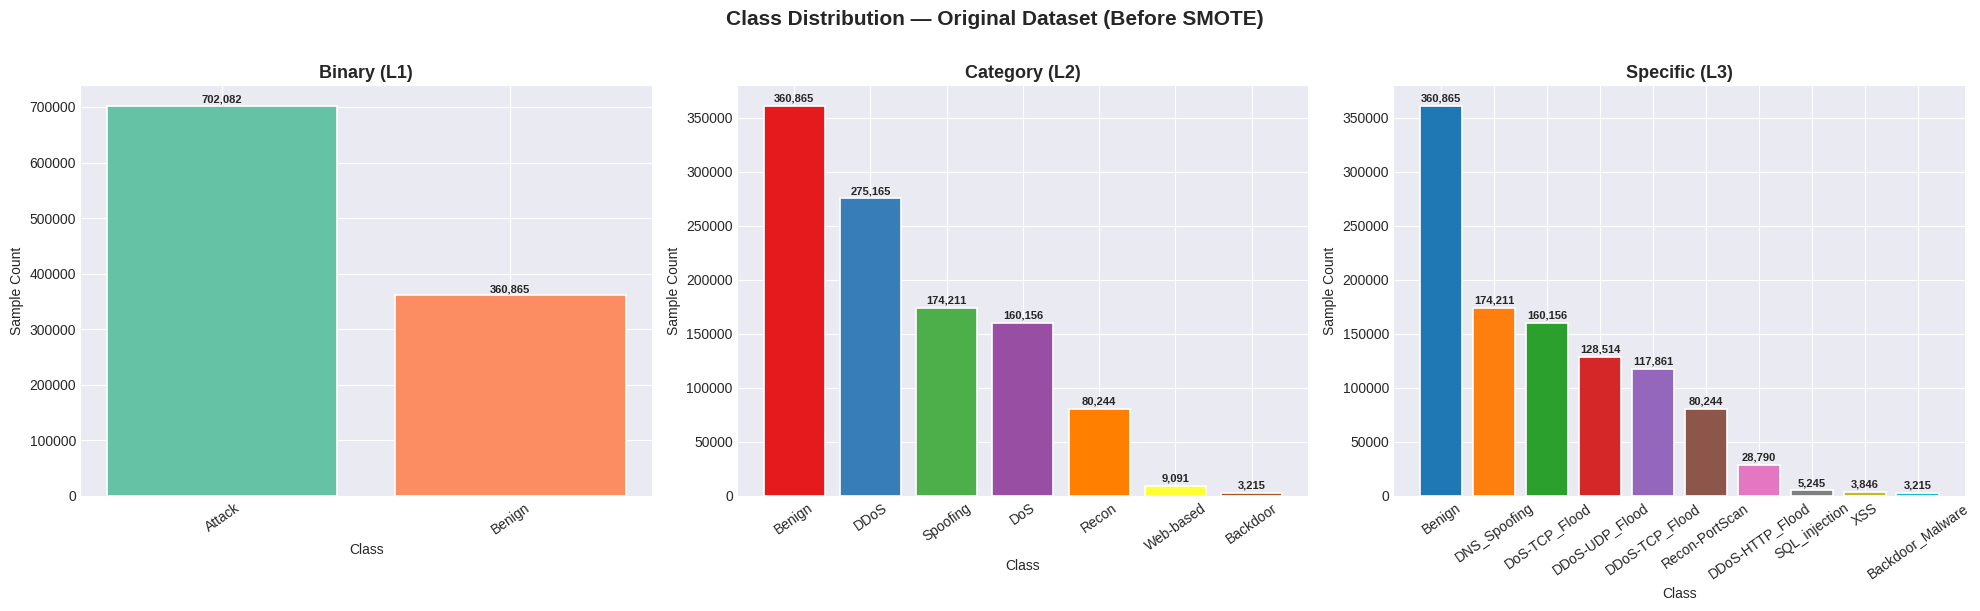

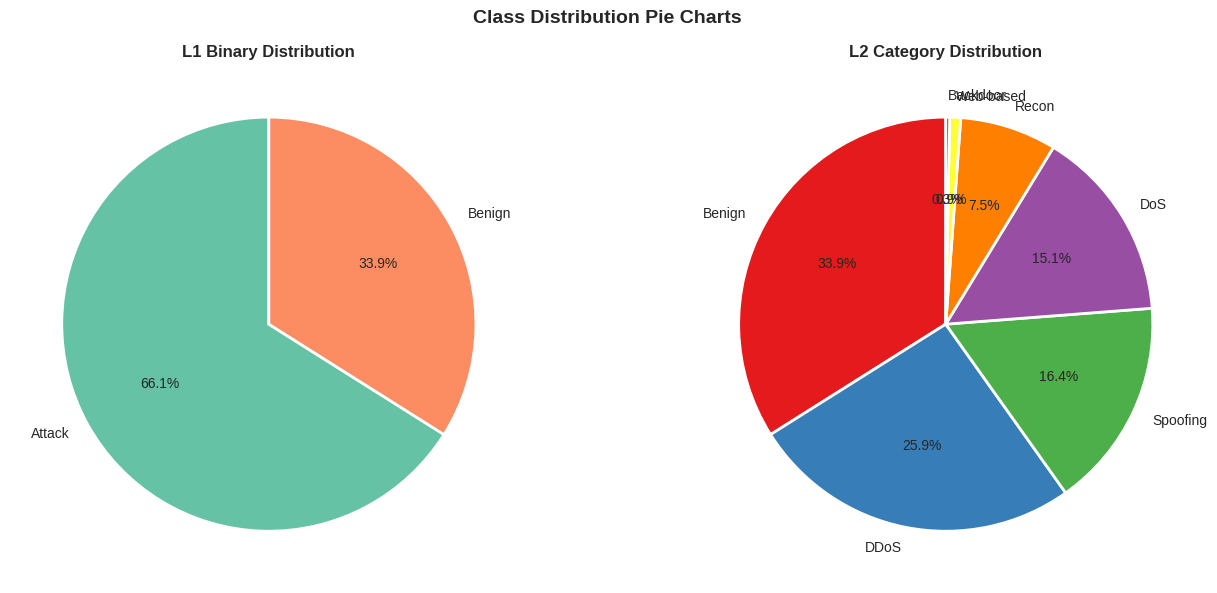


📋 Specific Label Counts (L3):


,Count,Pct (%)
specific_label,,
Benign,360865,33.95
DNS_Spoofing,174211,16.39
DoS-TCP_Flood,160156,15.07
DDoS-UDP_Flood,128514,12.09
DDoS-TCP_Flood,117861,11.09
Recon-PortScan,80244,7.55
DDoS-HTTP_Flood,28790,2.71
SQL_injection,5245,0.49
XSS,3846,0.36



🔥 Computing Correlation Heatmap (top 15 numeric features)...


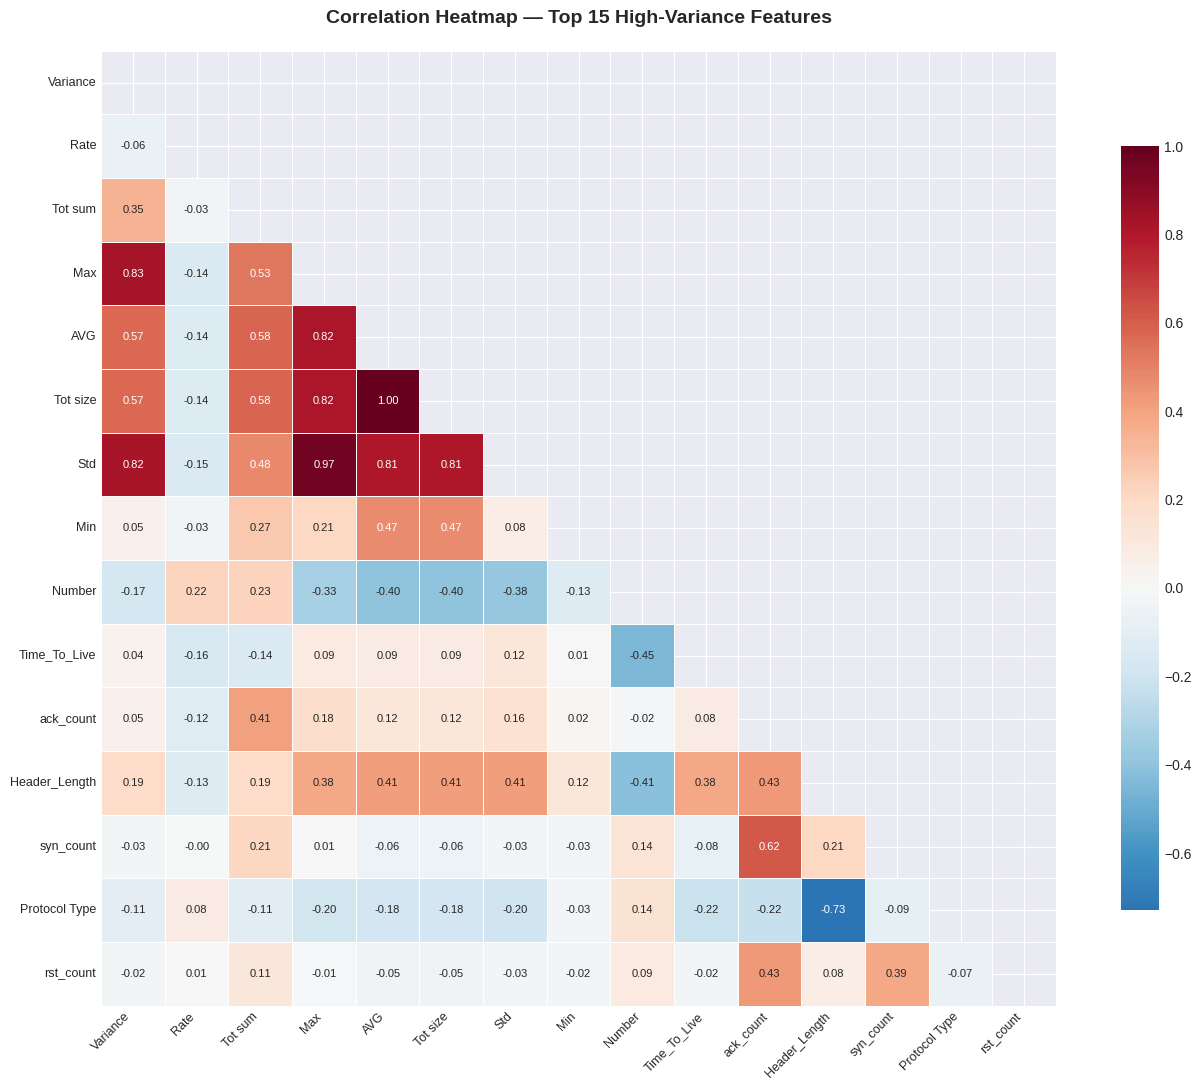


✅ EDA Complete!


In [4]:
# ============================================================
# BLOCK 3: EDA — ORIGINAL DATASET
# FIX: Missing values section now always shows a clear result
# FIX: num_cols excludes label columns for correct stats/corr
# ============================================================

print('='*70)
print('  EXPLORATORY DATA ANALYSIS — ORIGINAL DATASET')
print('='*70)

# --- 3.1 Basic Info ---
print(f'\n📐 Dataset Shape: {df.shape}')
print(f'📋 Total Columns: {df.shape[1]}')
print(f'📝 Total Rows:    {df.shape[0]:,}')

print('\n🔍 First 5 rows (first 8 columns):')
display(df.iloc[:, :8].head())

# --- 3.2 Missing Values (FIX: always shows a result clearly) ---
print('\n❓ Missing Values Analysis:')
miss_all = df.isnull().sum()
total_missing = miss_all.sum()
if total_missing == 0:
    print('  ✅ No missing values found in the entire dataset!')
    miss_df = pd.DataFrame({'Column': ['All columns'], 'Missing Count': [0], 'Missing %': [0.0]})
    display(miss_df)
else:
    miss_nonzero = miss_all[miss_all > 0].sort_values(ascending=False).head(15)
    miss_df = pd.DataFrame({
        'Column': miss_nonzero.index,
        'Missing Count': miss_nonzero.values,
        'Missing %': (miss_nonzero / len(df) * 100).round(2).values
    })
    print(f'  ⚠️  Total missing values: {total_missing:,} across {len(miss_nonzero)} columns')
    display(miss_df)
    # Only visualise if at least one column has > 0.1% missing — avoids
    # misleading bar chart for negligible missing values (e.g. 34 / 1M rows)
    if miss_df['Missing %'].max() > 0.1:
        plt.figure(figsize=(12, 4))
        plt.bar(miss_df['Column'], miss_df['Missing %'], color='tomato', edgecolor='white')
        plt.title('Missing Values (%) per Column', fontsize=13, fontweight='bold')
        plt.xticks(rotation=45, ha='right')
        plt.ylabel('Missing %')
        plt.tight_layout()
        plt.show()
    else:
        print('  ℹ️  Missing values are negligible (<0.1%) — filled with 0 in Block 5. No plot needed.')

# --- 3.3 Duplicate rows ---
n_dup = df.duplicated().sum()
print(f'\n🔁 Duplicate Rows: {n_dup:,} ({n_dup/len(df)*100:.2f}%)')
if n_dup > 0:
    print(f'  ⚠️  {n_dup:,} duplicate rows detected — dropping now...')
    df = df.drop_duplicates().reset_index(drop=True)
    print(f'  ✅ Duplicates dropped. New shape: {df.shape}')
else:
    print('  ✅ No duplicate rows found!')

# --- 3.4 Data Types ---
print(f'\n📊 Data Types Summary:')
dt_counts = df.dtypes.value_counts()
display(dt_counts.to_frame('Count'))

# --- 3.5 Numeric feature stats ---
# FIX: Explicitly exclude our injected label columns from numeric stats
INJECTED_LABEL_COLS = ['specific_label','category_label','attack_type']
num_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in INJECTED_LABEL_COLS
]
print(f'\n📈 Numeric Feature Statistics (first 8 of {len(num_cols)} features):')
display(df[num_cols[:8]].describe().T.round(3))

# --- 3.6 Class Distribution Bar Plots ---
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Class Distribution — Original Dataset (Before SMOTE)',
             fontsize=15, fontweight='bold', y=1.01)

levels = [
    ('Binary (L1)',   df['category_label'].apply(lambda x: 'Benign' if x=='Benign' else 'Attack')),
    ('Category (L2)', df['category_label']),
    ('Specific (L3)', df['specific_label']),
]
palettes = ['Set2', 'Set1', 'tab10']

for ax, (title, series), pal in zip(axes, levels, palettes):
    vc = series.value_counts()
    colors = sns.color_palette(pal, len(vc))
    bars = ax.bar(vc.index, vc.values, color=colors, edgecolor='white', linewidth=1.2)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Class', fontsize=10)
    ax.set_ylabel('Sample Count', fontsize=10)
    ax.tick_params(axis='x', rotation=35)
    for bar, val in zip(bars, vc.values):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + len(df)*0.002,
                f'{val:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3.7 Pie Charts ---
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))
fig2.suptitle('Class Distribution Pie Charts', fontsize=14, fontweight='bold')

binary_vc = df['category_label'].apply(
    lambda x: 'Benign' if x=='Benign' else 'Attack').value_counts()
cat_vc = df['category_label'].value_counts()

axes2[0].pie(binary_vc.values, labels=binary_vc.index, autopct='%1.1f%%',
             colors=sns.color_palette('Set2', 2), startangle=90,
             wedgeprops={'edgecolor':'white','linewidth':2})
axes2[0].set_title('L1 Binary Distribution', fontweight='bold')

axes2[1].pie(cat_vc.values, labels=cat_vc.index, autopct='%1.1f%%',
             colors=sns.color_palette('Set1', len(cat_vc)), startangle=90,
             wedgeprops={'edgecolor':'white','linewidth':2})
axes2[1].set_title('L2 Category Distribution', fontweight='bold')
plt.tight_layout()
plt.show()

# --- 3.8 Specific Label Counts ---
print('\n📋 Specific Label Counts (L3):')
spec_counts = df['specific_label'].value_counts().to_frame('Count')
spec_counts['Pct (%)'] = (spec_counts['Count'] / len(df) * 100).round(2)
display(spec_counts)

# --- 3.9 Correlation Heatmap (uses cleaned num_cols, no label cols) ---
print('\n🔥 Computing Correlation Heatmap (top 15 numeric features)...')
sample_for_corr = (
    df[num_cols]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .sample(min(10000, len(df)), random_state=RANDOM_STATE)
)
top15 = sample_for_corr.var().nlargest(15).index.tolist()
corr_mat = sample_for_corr[top15].corr()

plt.figure(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8},
            annot_kws={'size': 8})
plt.title('Correlation Heatmap — Top 15 High-Variance Features',
          fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)
plt.tight_layout()
plt.show()

print('\n✅ EDA Complete!')

------

## 🏷️ Block 4: Create Hierarchical Labels (Binary, Category, Specific)

In [5]:
# ============================================================
# BLOCK 4: CREATE HIERARCHICAL LABELS
# L1: Binary (Benign=0, Attack=1)
# L2: Category (DDoS, DoS, Recon, Web-based, Spoofing, Backdoor)
# L3: Specific attack types
# Ref: Uddin et al. 2025, Sarnovsky & Paralic 2020
# ============================================================

print('='*70)
print('  CREATING HIERARCHICAL LABELS')
print('='*70)

# L1: Binary
df['binary_label'] = df['category_label'].apply(lambda x: 0 if x == 'Benign' else 1)

# L2: Category (encode)
le_cat = LabelEncoder()
df['category_enc'] = le_cat.fit_transform(df['category_label'])

# L3: Specific (encode)
le_spec = LabelEncoder()
df['specific_enc'] = le_spec.fit_transform(df['specific_label'])

print('\n✅ Label Hierarchy:')
print('\n  L1 Binary Mapping:')
print('    0 = Benign')
print('    1 = Attack')

print('\n  L2 Category Classes:')
for i, c in enumerate(le_cat.classes_):
    print(f'    {i} = {c}')

print('\n  L3 Specific Attack Classes:')
for i, c in enumerate(le_spec.classes_):
    print(f'    {i} = {c}')

print('\n📊 Label Distribution Table:')
label_summary = df.groupby(
    ['category_label','specific_label']
).size().reset_index(name='Count')
label_summary['Binary'] = label_summary['category_label'].apply(
    lambda x: 'Benign' if x=='Benign' else 'Attack')
label_summary = label_summary[['Binary','category_label','specific_label','Count']]
label_summary.columns = ['L1 Binary','L2 Category','L3 Specific','Count']
label_summary['Pct (%)'] = (
    label_summary['Count'] / label_summary['Count'].sum() * 100).round(2)
display(label_summary)

print(f'\n📋 Summary:')
print(f'  L1 Classes: 2  (Benign, Attack)')
print(f'  L2 Classes: {len(le_cat.classes_)} — {list(le_cat.classes_)}')
print(f'  L3 Classes: {len(le_spec.classes_)} — {list(le_spec.classes_)}')

  CREATING HIERARCHICAL LABELS

✅ Label Hierarchy:

  L1 Binary Mapping:
    0 = Benign
    1 = Attack

  L2 Category Classes:
    0 = Backdoor
    1 = Benign
    2 = DDoS
    3 = DoS
    4 = Recon
    5 = Spoofing
    6 = Web-based

  L3 Specific Attack Classes:
    0 = Backdoor_Malware
    1 = Benign
    2 = DDoS-HTTP_Flood
    3 = DDoS-TCP_Flood
    4 = DDoS-UDP_Flood
    5 = DNS_Spoofing
    6 = DoS-TCP_Flood
    7 = Recon-PortScan
    8 = SQL_injection
    9 = XSS

📊 Label Distribution Table:


,L1 Binary,L2 Category,L3 Specific,Count,Pct (%)
0,Attack,Backdoor,Backdoor_Malware,3215,0.30
1,Benign,Benign,Benign,360865,33.95
2,Attack,DDoS,DDoS-HTTP_Flood,28790,2.71
3,Attack,DDoS,DDoS-TCP_Flood,117861,11.09
4,Attack,DDoS,DDoS-UDP_Flood,128514,12.09
5,Attack,DoS,DoS-TCP_Flood,160156,15.07
6,Attack,Recon,Recon-PortScan,80244,7.55
7,Attack,Spoofing,DNS_Spoofing,174211,16.39
8,Attack,Web-based,SQL_injection,5245,0.49
9,Attack,Web-based,XSS,3846,0.36



📋 Summary:
  L1 Classes: 2  (Benign, Attack)
  L2 Classes: 7 — ['Backdoor', 'Benign', 'DDoS', 'DoS', 'Recon', 'Spoofing', 'Web-based']
  L3 Classes: 10 — ['Backdoor_Malware', 'Benign', 'DDoS-HTTP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DNS_Spoofing', 'DoS-TCP_Flood', 'Recon-PortScan', 'SQL_injection', 'XSS']


------

## 🔧 Block 5: Feature Selection & Scaling

In [6]:
# ============================================================
# BLOCK 5: FEATURE SELECTION & CLEANING
# FIX (Data Leakage): Scaler moved to AFTER train/test split (Block 6).
# Fitting StandardScaler on the full dataset before splitting leaks
# test-set statistics (mean, std) into the scaler — a paper-breaking issue.
# This block now only defines feature_cols and cleans inf/NaN values.
# Scaling is done in Block 6: fit on train only, transform both.
# ============================================================

print('='*70)
print('  FEATURE SELECTION & CLEANING')
print('='*70)

# All label columns to exclude
label_cols_all = [
    'specific_label','category_label','attack_type',
    'binary_label','category_enc','specific_enc','attack_type_enc'
]

# Feature columns: numeric only, no label columns
feature_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if c not in label_cols_all
]

print(f'\n📊 Total numeric features: {len(feature_cols)}')
print(f'   First 10: {feature_cols[:10]}')

# Replace inf and fill NaN
print('\n🔧 Cleaning features (replace inf → NaN → 0)...')
df[feature_cols] = df[feature_cols].replace([np.inf, -np.inf], np.nan)
df[feature_cols] = df[feature_cols].fillna(0)

# Labels as numpy arrays (raw, unscaled — scaling happens in Block 6 after split)
y_binary   = df['binary_label'].values
y_category = df['category_enc'].values
y_specific = df['specific_enc'].values

print(f'\n✅ Feature matrix defined: {len(feature_cols)} features x {len(df):,} rows')
print(f'✅ L1 label shape: {y_binary.shape}')
print(f'✅ L2 label shape: {y_category.shape}')
print(f'✅ L3 label shape: {y_specific.shape}')
print('\n⚠️  NOTE: Scaling is intentionally deferred to Block 6.')
print('          scaler.fit_transform() runs on TRAIN only to prevent data leakage.')


  FEATURE SELECTION & CLEANING

📊 Total numeric features: 39
   First 10: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ece_flag_number']

🔧 Cleaning features (replace inf → NaN → 0)...

✅ Feature matrix defined: 39 features x 1,062,947 rows
✅ L1 label shape: (1062947,)
✅ L2 label shape: (1062947,)
✅ L3 label shape: (1062947,)

⚠️  NOTE: Scaling is intentionally deferred to Block 6.
          scaler.fit_transform() runs on TRAIN only to prevent data leakage.


------

## ✂️ Block 6: Train-Test Split (80/20 Stratified)

In [7]:
# ============================================================
# BLOCK 6: TRAIN-TEST SPLIT (80/20 Stratified) + SCALING
# FIX (Data Leakage): StandardScaler is now fit ONLY on training data.
# The scaler is applied here, after splitting, so test-set statistics
# never influence the scaler — eliminating the leakage from Block 5.
# Ref: Uddin et al. 2025, Sarnovsky & Paralic 2020
# ============================================================

print('='*70)
print('  TRAIN-TEST SPLIT (80/20 Stratified) + LEAK-FREE SCALING')
print('='*70)

# Raw (unscaled) feature matrix
X_raw = df[feature_cols].values

# ── Step 1: Split raw data ──
(
    X_train_raw, X_test_raw,
    y1_train, y1_test,
    y2_train, y2_test,
    y3_train, y3_test
) = train_test_split(
    X_raw, y_binary, y_category, y_specific,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_specific
)

# ── Step 2: Fit scaler on TRAIN only, transform both ──
# This is the correct order — the scaler never sees test data.
print('\n📏 Fitting StandardScaler on TRAIN set only (no leakage)...')
scaler = StandardScaler()
X_train_arr = scaler.fit_transform(X_train_raw)   # fit + transform train
X_test_arr  = scaler.transform(X_test_raw)         # transform only (no fit)

# Wrap in DataFrames for downstream compatibility
X_train = pd.DataFrame(X_train_arr, columns=feature_cols)
X_test  = pd.DataFrame(X_test_arr,  columns=feature_cols)

# NOTE: X_scaled and n_train removed — dead code. Block 12 CV uses X_train directly.

print(f'\n📊 Split + Scale Summary:')
print(f'  Train: {X_train.shape[0]:,} rows  ({X_train.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'  Test:  {X_test.shape[0]:,} rows  ({X_test.shape[0]/(X_train.shape[0]+X_test.shape[0])*100:.1f}%)')
print(f'  Features: {X_train.shape[1]}')
print(f'  Scaler fit on: {X_train.shape[0]:,} training rows ONLY ✅')

print('\n📋 L1 Binary — Train:')
tr_l1 = pd.Series(y1_train).map({0:'Benign',1:'Attack'}).value_counts()
display(tr_l1.to_frame('Train Count'))

print('\n📋 L1 Binary — Test:')
te_l1 = pd.Series(y1_test).map({0:'Benign',1:'Attack'}).value_counts()
display(te_l1.to_frame('Test Count'))

print('\n📋 L2 Category — Train:')
tr_l2 = pd.Series(le_cat.inverse_transform(y2_train)).value_counts()
display(tr_l2.to_frame('Train Count'))

print('\n📊 Scaled Feature Statistics — Train (first 8):')
display(X_train.iloc[:, :8].describe().T.round(4))

print('\n✅ Split + scaling complete! Scaler fitted on train set only.')


  TRAIN-TEST SPLIT (80/20 Stratified) + LEAK-FREE SCALING

📏 Fitting StandardScaler on TRAIN set only (no leakage)...

📊 Split + Scale Summary:
  Train: 850,357 rows  (80.0%)
  Test:  212,590 rows  (20.0%)
  Features: 39
  Scaler fit on: 850,357 training rows ONLY ✅

📋 L1 Binary — Train:


,Train Count
Attack,561665
Benign,288692



📋 L1 Binary — Test:


,Test Count
Attack,140417
Benign,72173



📋 L2 Category — Train:


,Train Count
Benign,288692
DDoS,220132
Spoofing,139368
DoS,128125
Recon,64195
Web-based,7273
Backdoor,2572



📊 Scaled Feature Statistics — Train (first 8):


,count,mean,std,min,25%,50%,75%,max
Header_Length,850357.0,-0.0,1.0,-2.4788,-0.4228,-0.1852,0.8108,4.3744
Protocol Type,850357.0,-0.0,1.0,-1.8322,-0.5357,-0.5357,-0.5357,1.8410
Time_To_Live,850357.0,0.0,1.0,-2.1242,-0.5560,-0.5295,0.2379,4.1241
Rate,850357.0,0.0,1.0,-0.3231,-0.3199,-0.2953,0.0311,167.8970
fin_flag_number,850357.0,-0.0,1.0,-0.3237,-0.3237,-0.3237,-0.3237,21.0402
syn_flag_number,850357.0,0.0,1.0,-0.2948,-0.2948,-0.2948,-0.2948,7.7167
rst_flag_number,850357.0,-0.0,1.0,-0.1637,-0.1637,-0.1637,-0.1637,10.0114
psh_flag_number,850357.0,0.0,1.0,-0.6766,-0.6766,-0.6766,0.6481,5.9472



✅ Split + scaling complete! Scaler fitted on train set only.


------

## ⚖️ Block 7: SMOTE Balancing + EDA After Balancing

  SMOTE CLASS BALANCING (CPU — standard for imbalanced-learn)
  Applied on TRAINING SET ONLY | k_neighbors=5
  XGBoost training in Block 8-10 uses GPU.

⚖️  Applying SMOTE for L1 (Binary)...
  Before: {np.int64(1): 561665, np.int64(0): 288692}
  After:  {np.int64(1): 561665, np.int64(0): 561665}
  Shape after SMOTE: (1123330, 39)

⚖️  Applying SMOTE for L2 (Category — attacks only)...
  Before: {np.int64(5): 139368, np.int64(3): 128125, np.int64(2): 220132, np.int64(4): 64195, np.int64(6): 7273, np.int64(0): 2572}
  After:  {np.int64(5): 220132, np.int64(3): 220132, np.int64(2): 220132, np.int64(4): 220132, np.int64(6): 220132, np.int64(0): 220132}
  Shape after SMOTE: (1320792, 39)

⚖️  Applying SMOTE for L3 (Specific Attack — attacks only)...
  Before: {np.int64(5): 139368, np.int64(6): 128125, np.int64(4): 102811, np.int64(7): 64195, np.int64(3): 94289, np.int64(2): 23032, np.int64(9): 3077, np.int64(8): 4196, np.int64(0): 2572}
  After:  {np.int64(5): 139368, np.int64(6): 139368, n

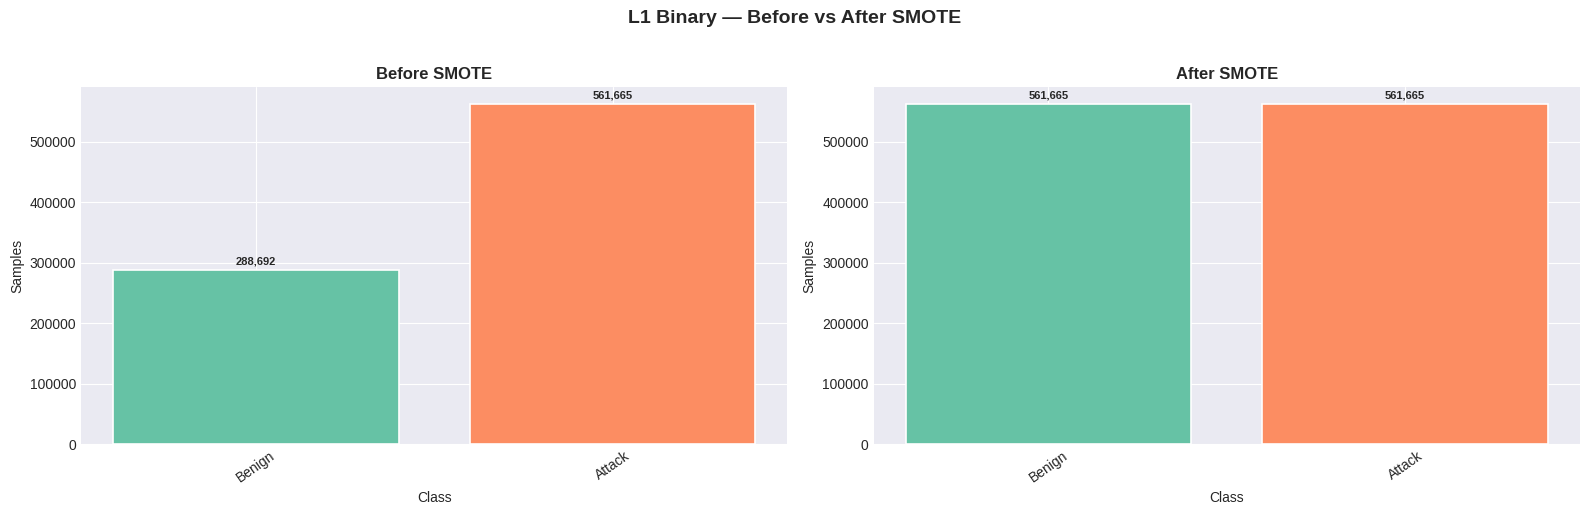

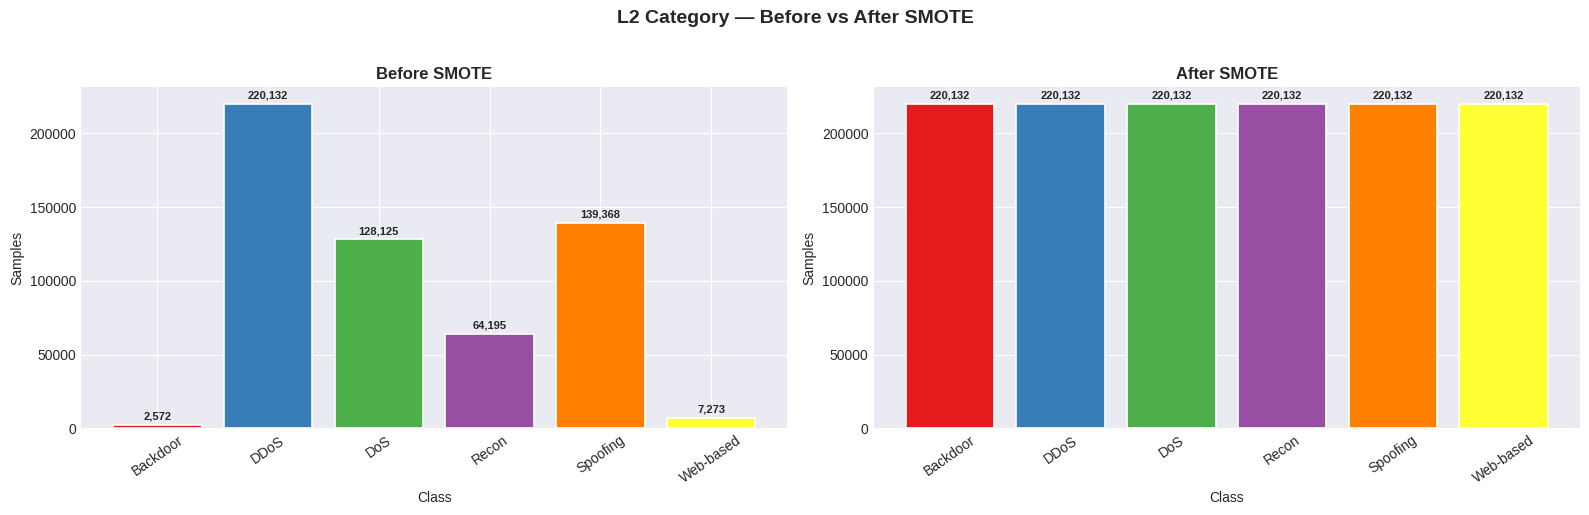

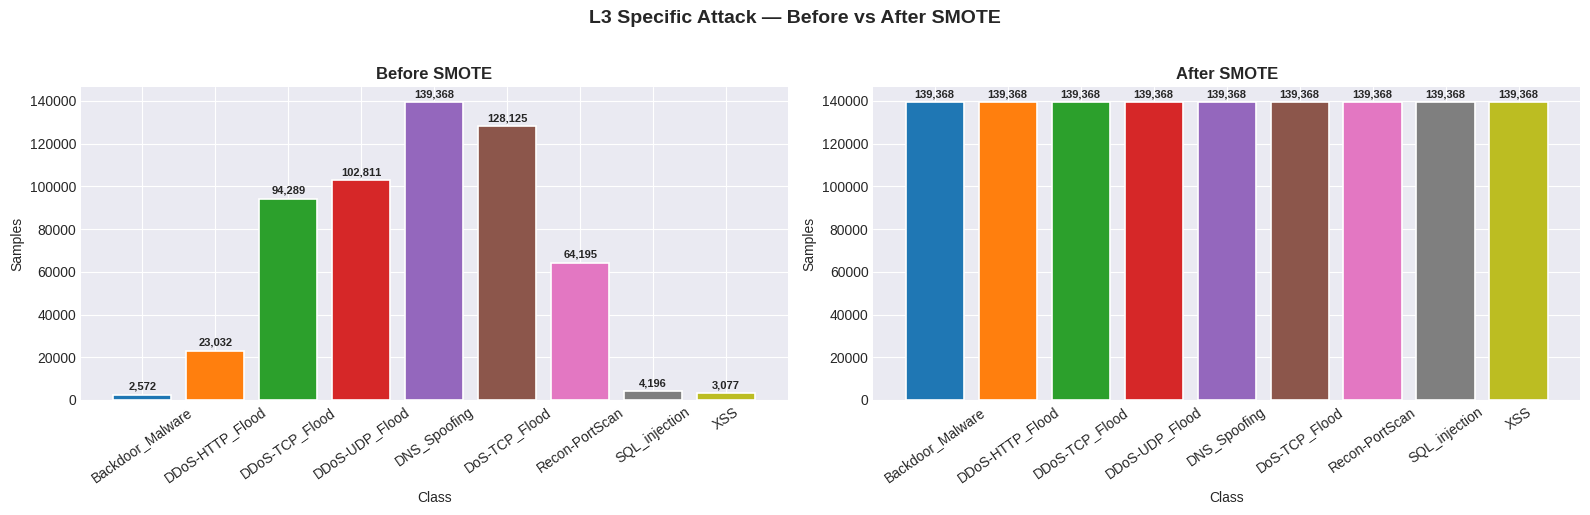


📋 SMOTE Summary Tables:

  L1 Binary:


,Class,Before SMOTE,After SMOTE,Added
0,Benign,288692,561665,272973
1,Attack,561665,561665,0



  L2 Category:


,Class,Before SMOTE,After SMOTE,Added
0,Backdoor,2572,220132,217560
1,DDoS,220132,220132,0
2,DoS,128125,220132,92007
3,Recon,64195,220132,155937
4,Spoofing,139368,220132,80764
5,Web-based,7273,220132,212859



  L3 Specific:


,Class,Before SMOTE,After SMOTE,Added
0,Backdoor_Malware,2572,139368,136796
1,DDoS-HTTP_Flood,23032,139368,116336
2,DDoS-TCP_Flood,94289,139368,45079
3,DDoS-UDP_Flood,102811,139368,36557
4,DNS_Spoofing,139368,139368,0
5,DoS-TCP_Flood,128125,139368,11243
6,Recon-PortScan,64195,139368,75173
7,SQL_injection,4196,139368,135172
8,XSS,3077,139368,136291




✅ SMOTE balancing complete!


In [8]:
# ============================================================
# BLOCK 7: SMOTE BALANCING + EDA AFTER BALANCING
# SMOTE(k=5) on TRAINING SET ONLY at each level
# NOTE: SMOTE runs on CPU — imbalanced-learn has no GPU backend.
#       This is standard practice. XGBoost training uses GPU.
# Ref: Sample-Based Multistage ML Pipeline for IoT
# FIX: Removed all dead commented-out cuML GPU code
# FIX: SMOTE outputs are numpy arrays — .values NOT needed later
# ============================================================

print('='*70)
print('  SMOTE CLASS BALANCING (CPU — standard for imbalanced-learn)')
print('='*70)
print('  Applied on TRAINING SET ONLY | k_neighbors=5')
print('  XGBoost training in Block 8-10 uses GPU.')
print('='*70)

# ── L1 SMOTE (Binary) ──
print('\n⚖️  Applying SMOTE for L1 (Binary)...')
l1_before = Counter(y1_train)
smote_l1 = SMOTE(k_neighbors=5, random_state=RANDOM_STATE)
# FIX: SMOTE returns numpy arrays, store as-is
X1_res, y1_res = smote_l1.fit_resample(X_train.values, y1_train)
l1_after = Counter(y1_res)
print(f'  Before: {dict(l1_before)}')
print(f'  After:  {dict(l1_after)}')
print(f'  Shape after SMOTE: {X1_res.shape}')

# ── L2 SMOTE (Category — attacks only) ──
print('\n⚖️  Applying SMOTE for L2 (Category — attacks only)...')
attack_mask_train = (y1_train == 1)
# FIX: use .values to ensure numpy array for SMOTE input
X2_train_np = X_train.values[attack_mask_train]
y2_train_att = y2_train[attack_mask_train]

l2_before = Counter(y2_train_att)
min_count_l2 = min(l2_before.values())
k_l2 = min(5, min_count_l2 - 1) if min_count_l2 > 1 else 1
smote_l2 = SMOTE(k_neighbors=k_l2, random_state=RANDOM_STATE)
X2_res, y2_res = smote_l2.fit_resample(X2_train_np, y2_train_att)
l2_after = Counter(y2_res)
print(f'  Before: {dict(l2_before)}')
print(f'  After:  {dict(l2_after)}')
print(f'  Shape after SMOTE: {X2_res.shape}')

# ── L3 SMOTE (Specific — attacks only) ──
print('\n⚖️  Applying SMOTE for L3 (Specific Attack — attacks only)...')
X3_train_np = X_train.values[attack_mask_train]
y3_train_att = y3_train[attack_mask_train]

l3_before = Counter(y3_train_att)
min_count_l3 = min(l3_before.values())
k_l3 = min(5, min_count_l3 - 1) if min_count_l3 > 1 else 1
smote_l3 = SMOTE(k_neighbors=k_l3, random_state=RANDOM_STATE)
X3_res, y3_res = smote_l3.fit_resample(X3_train_np, y3_train_att)
l3_after = Counter(y3_res)
print(f'  Before: {dict(l3_before)}')
print(f'  After:  {dict(l3_after)}')
print(f'  Shape after SMOTE: {X3_res.shape}')

gc.collect()

# ── EDA: Before vs After SMOTE Plots ──
print('\n📊 Plotting Before vs After SMOTE distributions...')

def plot_before_after(before_counter, after_counter, label_encoder, title, palette='husl'):
    """Side-by-side bar plots: before vs after SMOTE."""
    def get_labels(ctr):
        labels, vals = [], []
        for k in sorted(ctr.keys()):
            try:
                lbl = label_encoder.inverse_transform([k])[0]
            except Exception:
                lbl = str(k)
            labels.append(lbl)
            vals.append(ctr[k])
        return labels, vals

    b_labels, b_vals = get_labels(before_counter)
    a_labels, a_vals = get_labels(after_counter)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(title, fontsize=14, fontweight='bold', y=1.02)

    for ax, labels, vals, subtitle in [
        (axes[0], b_labels, b_vals, 'Before SMOTE'),
        (axes[1], a_labels, a_vals, 'After SMOTE'),
    ]:
        colors = sns.color_palette(palette, len(labels))
        bars = ax.bar(labels, vals, color=colors, edgecolor='white', linewidth=1.2)
        ax.set_title(subtitle, fontsize=12, fontweight='bold')
        ax.set_xlabel('Class'); ax.set_ylabel('Samples')
        ax.tick_params(axis='x', rotation=35)
        for bar, v in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2,
                    bar.get_height() + max(vals)*0.01,
                    f'{v:,}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    plt.tight_layout()
    plt.show()


class BinaryEncoder:
    """Simple encoder for binary labels."""
    def inverse_transform(self, x):
        return ['Benign' if v==0 else 'Attack' for v in x]

be = BinaryEncoder()
plot_before_after(l1_before, l1_after, be,   'L1 Binary — Before vs After SMOTE',          'Set2')
plot_before_after(l2_before, l2_after, le_cat, 'L2 Category — Before vs After SMOTE',       'Set1')
plot_before_after(l3_before, l3_after, le_spec,'L3 Specific Attack — Before vs After SMOTE','tab10')

# Summary Tables
print('\n📋 SMOTE Summary Tables:\n')
for name, before, after, enc in [
    ('L1 Binary',   l1_before, l1_after, be),
    ('L2 Category', l2_before, l2_after, le_cat),
    ('L3 Specific', l3_before, l3_after, le_spec),
]:
    rows = []
    for k in sorted(set(list(before.keys()) + list(after.keys()))):
        try:
            lbl = enc.inverse_transform([k])[0]
        except Exception:
            lbl = str(k)
        b = before.get(k, 0); a = after.get(k, 0)
        rows.append({'Class': lbl, 'Before SMOTE': b, 'After SMOTE': a, 'Added': a-b})
    print(f'  {name}:')
    display(pd.DataFrame(rows))
    print()

print('\n✅ SMOTE balancing complete!')

------

## 🌲 Block 8: Train L1 Binary XGBoost (GPU)

  LEVEL 1 — BINARY XGBOOST (GPU)

  L1 params: objective=binary:logistic, eval_metric=logloss
  L2/L3 params: objective=multi:softmax, eval_metric=mlogloss
  Training on 1,123,330 SMOTE-balanced samples | device=cuda
  L1 best iteration: 299

✅ L1 Training Complete!
   Accuracy:  0.9303
   Precision: 0.9151
   Recall:    0.9401
   F1-Macro:  0.9247
   AUC:       0.9801

📊 L1 Classification Report:
              precision    recall  f1-score   support

      Benign       0.85      0.97      0.90     72173
      Attack       0.98      0.91      0.95    140417

    accuracy                           0.93    212590
   macro avg       0.92      0.94      0.92    212590
weighted avg       0.94      0.93      0.93    212590



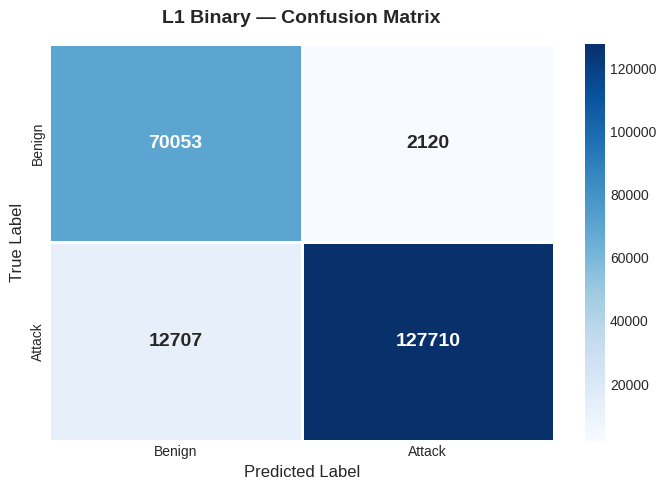

In [9]:
# ============================================================
# BLOCK 8: TRAIN L1 BINARY XGBOOST — GPU ACCELERATED
# Ref: XAI-XGBoost for Securing IoT Systems
#      Two-Stage Network IDS for IoT Traffic
# ROOT CAUSE FIX: XGB_PARAMS used eval_metric='mlogloss' for binary.
# XGBoost binary classifier uses num_class=1 internally, so mlogloss
# validates label in [0,1) — label=1 fails → XGBoostError.
# FIX: Separate params: XGB_PARAMS_BIN for L1, XGB_PARAMS_MULTI for L2/L3
# ============================================================

print('='*70)
print('  LEVEL 1 — BINARY XGBOOST (GPU)')
print('='*70)

# ── Binary-specific params: objective=binary:logistic, eval_metric=logloss ──
XGB_PARAMS_BIN = dict(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective='binary:logistic',   # explicit binary objective
    eval_metric='logloss',         # logloss is correct for binary
    tree_method='hist',
    device=XGB_DEVICE,
    random_state=RANDOM_STATE,
)

# ── Multiclass params for L2 and L3 ──
XGB_PARAMS_MULTI = dict(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.1,
    objective='multi:softmax',     # explicit multiclass objective
    eval_metric='mlogloss',        # mlogloss correct for multiclass
    tree_method='hist',
    device=XGB_DEVICE,
    random_state=RANDOM_STATE,
)

print(f'\n  L1 params: objective={XGB_PARAMS_BIN["objective"]}, eval_metric={XGB_PARAMS_BIN["eval_metric"]}')
print(f'  L2/L3 params: objective={XGB_PARAMS_MULTI["objective"]}, eval_metric={XGB_PARAMS_MULTI["eval_metric"]}')
print(f'  Training on {X1_res.shape[0]:,} SMOTE-balanced samples | device={XGB_DEVICE}')

# X1_res is numpy array (from SMOTE) — pass directly, no .values needed
# FIX: carve 10% val from SMOTE train data — test set never seen during training.
# early_stopping_rounds requires a proper val set (not the test set).
X1_tr, X1_val, y1_tr, y1_val = train_test_split(
    X1_res, y1_res, test_size=0.1, random_state=RANDOM_STATE, stratify=y1_res
)
xgb_l1 = xgb.XGBClassifier(**XGB_PARAMS_BIN, early_stopping_rounds=30)
xgb_l1.fit(
    X1_tr, y1_tr,
    eval_set=[(X1_val, y1_val)],   # val from train data only — no test leakage
    verbose=False
)
print(f'  L1 best iteration: {xgb_l1.best_iteration}')

y1_pred = xgb_l1.predict(X_test.values)
y1_prob = xgb_l1.predict_proba(X_test.values)

acc_l1  = accuracy_score(y1_test, y1_pred)
prec_l1 = precision_score(y1_test, y1_pred, average='macro', zero_division=0)
rec_l1  = recall_score(y1_test, y1_pred,    average='macro', zero_division=0)
f1_l1   = f1_score(y1_test, y1_pred,        average='macro', zero_division=0)
try:
    auc_l1 = roc_auc_score(y1_test, y1_prob[:, 1])
except Exception:
    auc_l1 = float('nan')

print(f'\n✅ L1 Training Complete!')
print(f'   Accuracy:  {acc_l1:.4f}')
print(f'   Precision: {prec_l1:.4f}')
print(f'   Recall:    {rec_l1:.4f}')
print(f'   F1-Macro:  {f1_l1:.4f}')
print(f'   AUC:       {auc_l1:.4f}')

print('\n📊 L1 Classification Report:')
print(classification_report(y1_test, y1_pred,
                             target_names=['Benign','Attack'], zero_division=0))

cm1 = confusion_matrix(y1_test, y1_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign','Attack'],
            yticklabels=['Benign','Attack'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 14, 'weight': 'bold'})
plt.title('L1 Binary — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()


------

## 🌲 Block 9: Train L2 Category XGBoost — Attacks Only (GPU)

  LEVEL 2 — CATEGORY XGBOOST (ATTACKS ONLY) — GPU
  Training on 1,320,792 SMOTE-balanced attack samples | device=cuda
  Classes (6): ['Backdoor', 'DDoS', 'DoS', 'Recon', 'Spoofing', 'Web-based']
  L2 best iteration: 299

✅ L2 Training Complete!
   Accuracy:  0.9019
   Precision: 0.6886
   Recall:    0.7069
   F1-Macro:  0.6931
   AUC:       0.9850

📊 L2 Classification Report:
              precision    recall  f1-score   support

    Backdoor       0.18      0.34      0.24       643
        DDoS       0.90      0.95      0.93     55033
         DoS       0.91      0.82      0.86     32031
       Recon       0.88      0.88      0.88     16049
    Spoofing       0.96      0.95      0.95     34843
   Web-based       0.30      0.30      0.30      1818

    accuracy                           0.90    140417
   macro avg       0.69      0.71      0.69    140417
weighted avg       0.91      0.90      0.90    140417



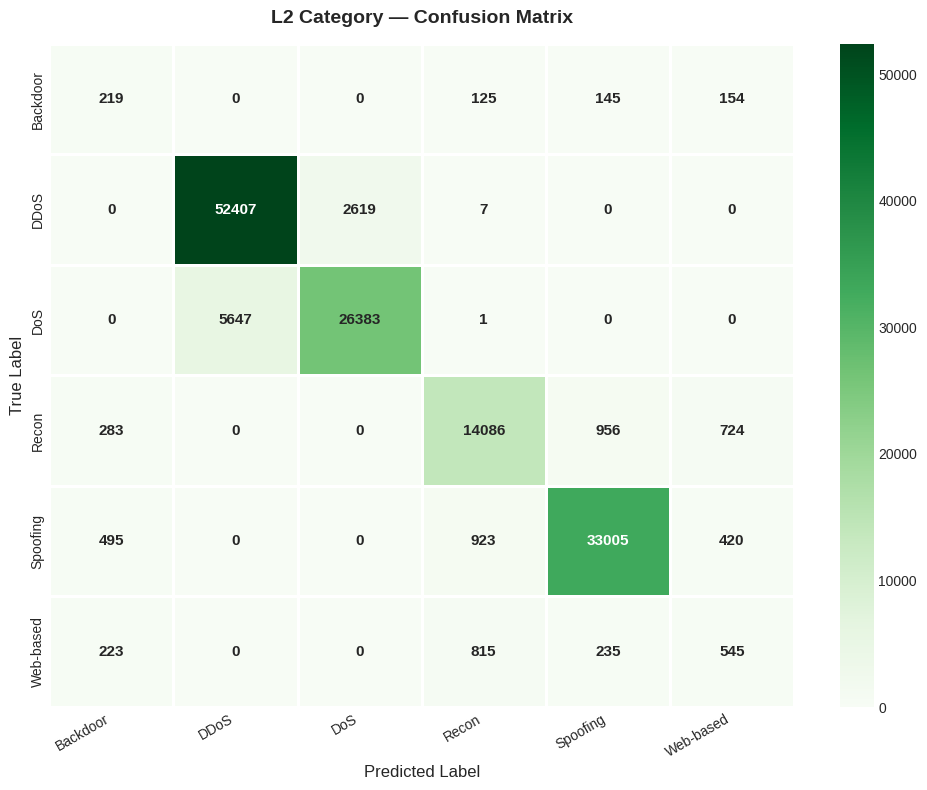

In [10]:
# ============================================================
# BLOCK 9: TRAIN L2 CATEGORY XGBOOST (ATTACKS ONLY) — GPU
# Ref: Hierarchical IDS — Sarnovsky & Paralic 2020
#      Scalable Hierarchical IDS — Uddin et al. 2025
# FIX: Use XGB_PARAMS_MULTI (multi:softmax + mlogloss) for multiclass
# FIX: X2_res is numpy array — no .values call needed
# FIX: le_cat2 was fit on already-encoded integers (from SMOTE output),
#      so le_cat2.classes_ was [np.int64(0), np.int64(2), ...] — NOT strings.
#      classification_report / heatmap crashed with TypeError: len(np.int64).
#      FIXED: derive string class names by inverse_transform through original le_cat.
# ============================================================

print('='*70)
print('  LEVEL 2 — CATEGORY XGBOOST (ATTACKS ONLY) — GPU')
print('='*70)

# Filter test set to attacks only
attack_mask_test = (y1_test == 1)
X2_test     = X_test.values[attack_mask_test]   # numpy array
y2_test_att = y2_test[attack_mask_test]

# ── Re-encode to contiguous 0-based labels for XGBoost ──
# y2_res and y2_test_att are integer-encoded categories (from le_cat).
# Some category codes may be missing (e.g. Benign=0 excluded), so we
# must re-map the present codes -> 0, 1, 2, ... to avoid XGBoost gaps.
unique_l2       = np.array(sorted(np.unique(y2_res)))          # e.g. [0,2,3,4,5,6]
y2_res_enc      = np.searchsorted(unique_l2, y2_res)           # 0-based
y2_test_enc     = np.searchsorted(unique_l2, y2_test_att)      # 0-based

# FIX: get REAL string class names from the original le_cat encoder
cat_names_str   = le_cat.inverse_transform(unique_l2)          # e.g. ['Backdoor', 'DDoS', ...]
le_cat2_classes = cat_names_str                                 # kept for Block 15 compatibility

print(f'  Training on {X2_res.shape[0]:,} SMOTE-balanced attack samples | device={XGB_DEVICE}')
print(f'  Classes ({len(cat_names_str)}): {list(cat_names_str)}')

# X2_res is numpy array from SMOTE — pass directly, use XGB_PARAMS_MULTI
# FIX: carve 10% val from SMOTE train data — test set never seen during training.
X2_tr, X2_val, y2_tr, y2_val = train_test_split(
    X2_res, y2_res_enc, test_size=0.1, random_state=RANDOM_STATE, stratify=y2_res_enc
)
xgb_l2 = xgb.XGBClassifier(**XGB_PARAMS_MULTI, early_stopping_rounds=30)
xgb_l2.set_params(num_class=len(unique_l2))  # explicit num_class avoids eval_set class-count mismatch
xgb_l2.fit(
    X2_tr, y2_tr,
    eval_set=[(X2_val, y2_val)],   # val from train data only — no test leakage
    verbose=False
)
print(f'  L2 best iteration: {xgb_l2.best_iteration}')

y2_pred = xgb_l2.predict(X2_test)
y2_prob = xgb_l2.predict_proba(X2_test)

acc_l2  = accuracy_score(y2_test_enc, y2_pred)
prec_l2 = precision_score(y2_test_enc, y2_pred, average='macro', zero_division=0)
rec_l2  = recall_score(y2_test_enc, y2_pred,    average='macro', zero_division=0)
f1_l2   = f1_score(y2_test_enc, y2_pred,        average='macro', zero_division=0)
try:
    auc_l2 = roc_auc_score(y2_test_enc, y2_prob, multi_class='ovr', average='macro')
except Exception:
    auc_l2 = float('nan')

print(f'\n✅ L2 Training Complete!')
print(f'   Accuracy:  {acc_l2:.4f}')
print(f'   Precision: {prec_l2:.4f}')
print(f'   Recall:    {rec_l2:.4f}')
print(f'   F1-Macro:  {f1_l2:.4f}')
print(f'   AUC:       {auc_l2:.4f}')

# FIX: use cat_names_str (real string labels) not le_cat2.classes_ (int64 array)
cat_names = cat_names_str
print('\n📊 L2 Classification Report:')
print(classification_report(y2_test_enc, y2_pred, target_names=cat_names, zero_division=0))

cm2 = confusion_matrix(y2_test_enc, y2_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=cat_names, yticklabels=cat_names,
            linewidths=0.8, linecolor='white',
            annot_kws={'size': 11, 'weight': 'bold'})
plt.title('L2 Category — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()


------

## 🌲 Block 10: Train L3 Specific XGBoost — Attacks Only (GPU)

  LEVEL 3 — SPECIFIC ATTACK XGBOOST (ATTACKS ONLY) — GPU
  Training on 1,254,312 SMOTE-balanced attack samples | device=cuda
  Classes (9): ['Backdoor_Malware', 'DDoS-HTTP_Flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DNS_Spoofing', 'DoS-TCP_Flood', 'Recon-PortScan', 'SQL_injection', 'XSS']
  L3 best iteration: 299

✅ L3 Training Complete!
   Accuracy:  0.9045
   Precision: 0.6963
   Recall:    0.7119
   F1-Macro:  0.6988
   AUC:       0.9872

📊 L3 Classification Report:
                  precision    recall  f1-score   support

Backdoor_Malware       0.21      0.28      0.24       643
 DDoS-HTTP_Flood       0.99      1.00      1.00      5758
  DDoS-TCP_Flood       0.76      0.97      0.85     23572
  DDoS-UDP_Flood       1.00      1.00      1.00     25703
    DNS_Spoofing       0.96      0.95      0.96     34843
   DoS-TCP_Flood       0.97      0.78      0.86     32031
  Recon-PortScan       0.88      0.88      0.88     16049
   SQL_injection       0.27      0.20      0.23      1049
  

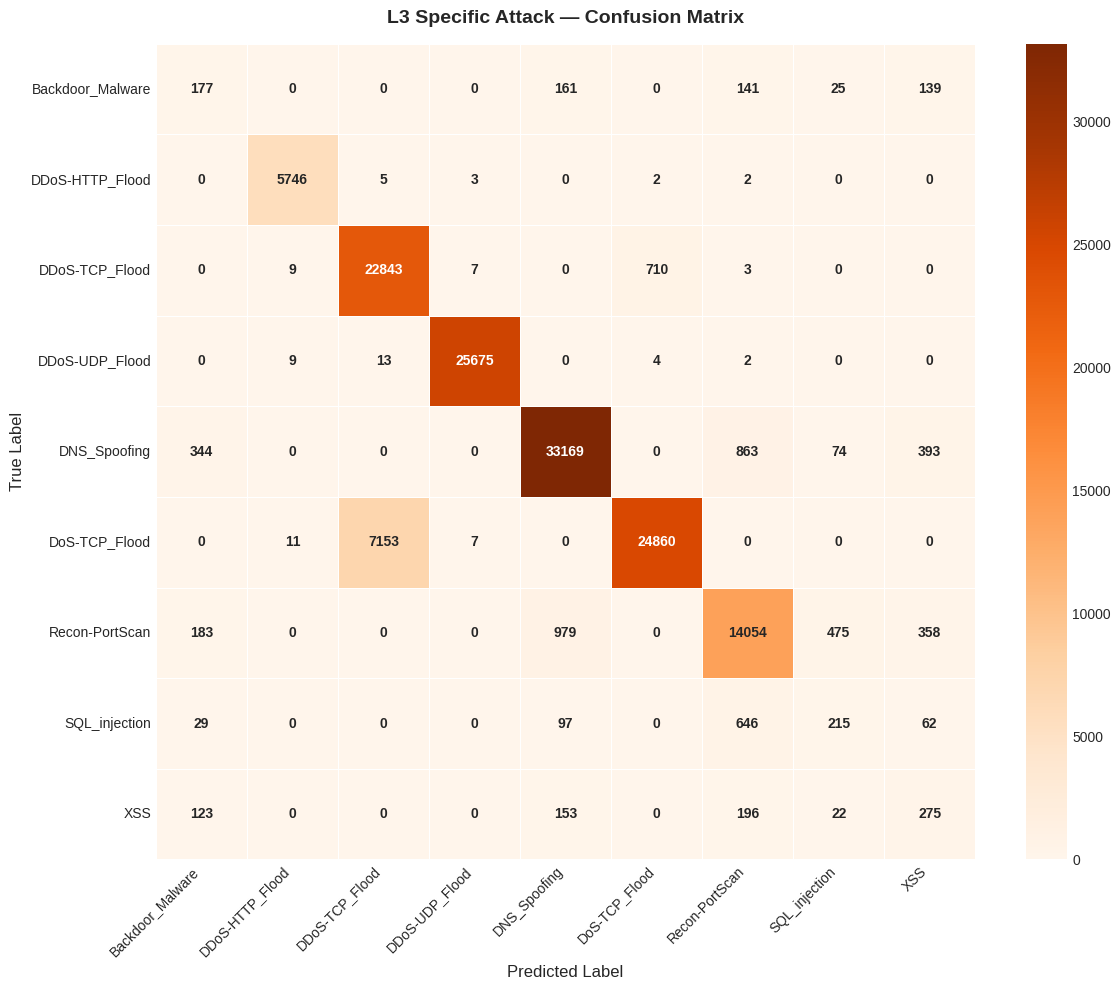

In [11]:
# ============================================================
# BLOCK 10: TRAIN L3 SPECIFIC XGBOOST (ATTACKS ONLY) — GPU
# Ref: Multi-Stage Adversarial Defense for DDoS in IoT
# FIX: X3_res is numpy array — no .values call needed
# FIX: X3_test set as numpy array
# FIX: le_spec2 was fit on already-encoded integers -> classes_ were np.int64.
#      classification_report / heatmap crashed. FIXED same way as L2:
#      use np.searchsorted for re-encoding + le_spec.inverse_transform for names.
# ============================================================

print('='*70)
print('  LEVEL 3 — SPECIFIC ATTACK XGBOOST (ATTACKS ONLY) — GPU')
print('='*70)

# X3_test: attack rows from test set (numpy)
X3_test     = X_test.values[attack_mask_test]   # numpy array
y3_test_att = y3_test[attack_mask_test]

# ── Re-encode to contiguous 0-based labels for XGBoost ──
unique_l3       = np.array(sorted(np.unique(y3_res)))
y3_res_enc      = np.searchsorted(unique_l3, y3_res)
y3_test_enc     = np.searchsorted(unique_l3, y3_test_att)

# FIX: get REAL string class names from the original le_spec encoder
spec_names_str  = le_spec.inverse_transform(unique_l3)
le_spec2_classes = spec_names_str                               # kept for Block 15 compatibility

print(f'  Training on {X3_res.shape[0]:,} SMOTE-balanced attack samples | device={XGB_DEVICE}')
print(f'  Classes ({len(spec_names_str)}): {list(spec_names_str)}')

# X3_res is numpy array from SMOTE — pass directly
# FIX: carve 10% val from SMOTE train data — test set never seen during training.
X3_tr, X3_val, y3_tr, y3_val = train_test_split(
    X3_res, y3_res_enc, test_size=0.1, random_state=RANDOM_STATE, stratify=y3_res_enc
)
xgb_l3 = xgb.XGBClassifier(**XGB_PARAMS_MULTI, early_stopping_rounds=30)
xgb_l3.set_params(num_class=len(unique_l3))  # explicit num_class avoids eval_set class-count mismatch
xgb_l3.fit(
    X3_tr, y3_tr,
    eval_set=[(X3_val, y3_val)],   # val from train data only — no test leakage
    verbose=False
)
print(f'  L3 best iteration: {xgb_l3.best_iteration}')

y3_pred = xgb_l3.predict(X3_test)
y3_prob = xgb_l3.predict_proba(X3_test)

acc_l3  = accuracy_score(y3_test_enc, y3_pred)
prec_l3 = precision_score(y3_test_enc, y3_pred, average='macro', zero_division=0)
rec_l3  = recall_score(y3_test_enc, y3_pred,    average='macro', zero_division=0)
f1_l3   = f1_score(y3_test_enc, y3_pred,         average='macro', zero_division=0)
try:
    auc_l3 = roc_auc_score(y3_test_enc, y3_prob, multi_class='ovr', average='macro')
except Exception:
    auc_l3 = float('nan')

print(f'\n✅ L3 Training Complete!')
print(f'   Accuracy:  {acc_l3:.4f}')
print(f'   Precision: {prec_l3:.4f}')
print(f'   Recall:    {rec_l3:.4f}')
print(f'   F1-Macro:  {f1_l3:.4f}')
print(f'   AUC:       {auc_l3:.4f}')

# FIX: use spec_names_str (real string labels) not le_spec2.classes_ (int64 array)
spec_names = spec_names_str
print('\n📊 L3 Classification Report:')
print(classification_report(y3_test_enc, y3_pred, target_names=spec_names, zero_division=0))

cm3 = confusion_matrix(y3_test_enc, y3_pred)
fig_sz = max(12, len(spec_names))
plt.figure(figsize=(fig_sz, fig_sz-2))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Oranges',
            xticklabels=spec_names, yticklabels=spec_names,
            linewidths=0.6, linecolor='white',
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title('L3 Specific Attack — Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


------

## 🔀 Block 11: Hierarchical Prediction Function

In [12]:
# ============================================================
# BLOCK 11: HIERARCHICAL PREDICTION FUNCTION
# Branched inference: L1 -> if Attack -> L2 + L3
# Ref: Scalable Hierarchical IDS (Uddin et al. 2025)
#      Hierarchical IDS (Sarnovsky & Paralic 2020)
# FIX: le_cat2/le_spec2 no longer exist as LabelEncoders (removed in Block 9/10 fix).
#      Replaced with direct index lookup into cat_names_str / spec_names_str arrays.
# ============================================================

def hierarchical_predict(X_input, xgb_l1, xgb_l2, xgb_l3, cat_names, spec_names):
    """
    Branched hierarchical inference:
      L1: Binary (Benign vs Attack)
      If Attack -> L2: Category + L3: Specific type
    cat_names / spec_names: arrays of string labels (0-indexed, matching XGBoost output)
    """
    X_arr = X_input.values if isinstance(X_input, pd.DataFrame) else X_input
    n = len(X_arr)

    results = {
        'binary':         np.zeros(n, dtype=int),
        'binary_label':   ['Benign'] * n,
        'category':       np.full(n, -1, dtype=int),
        'category_label': ['N/A'] * n,
        'specific':       np.full(n, -1, dtype=int),
        'specific_label': ['N/A'] * n,
    }

    l1_preds = xgb_l1.predict(X_arr)
    results['binary']       = l1_preds
    results['binary_label'] = ['Attack' if p==1 else 'Benign' for p in l1_preds]

    attack_idx = np.where(l1_preds == 1)[0]
    if len(attack_idx) > 0:
        X_att    = X_arr[attack_idx]
        l2_preds = xgb_l2.predict(X_att)
        l3_preds = xgb_l3.predict(X_att)
        for i, idx in enumerate(attack_idx):
            results['category'][idx]       = l2_preds[i]
            results['category_label'][idx] = cat_names[l2_preds[i]]
            results['specific'][idx]       = l3_preds[i]
            results['specific_label'][idx] = spec_names[l3_preds[i]]

    return pd.DataFrame(results)


print('='*70)
print('  HIERARCHICAL PREDICTION DEMO')
print('='*70)
print('\n🔮 Running branched hierarchical prediction on 20 test samples...')

# FIX: pass cat_names_str / spec_names_str (string arrays) instead of LabelEncoders
demo_results = hierarchical_predict(
    X_test.iloc[:20], xgb_l1, xgb_l2, xgb_l3, cat_names_str, spec_names_str
)
print('\n📋 Hierarchical Prediction Results (20 samples):')
display(demo_results[['binary_label','category_label','specific_label']])

print(f'\n  Benign: {(demo_results["binary_label"]=="Benign").sum()}')
print(f'  Attack: {(demo_results["binary_label"]=="Attack").sum()}')

print('\n✅ Hierarchical inference function ready!')
print('\n🏗️  Architecture:')
print('  Input -> L1 (Binary) ----> Benign (stop)')
print('                       |---> Attack -> L2 (Category)')
print('                                   -> L3 (Specific Type)')


  HIERARCHICAL PREDICTION DEMO

🔮 Running branched hierarchical prediction on 20 test samples...

📋 Hierarchical Prediction Results (20 samples):


,binary_label,category_label,specific_label
0,Attack,DDoS,DDoS-UDP_Flood
1,Benign,N/A,N/A
2,Attack,DDoS,DDoS-TCP_Flood
3,Attack,DDoS,DDoS-UDP_Flood
4,Benign,N/A,N/A
5,Attack,Recon,Recon-PortScan
6,Benign,N/A,N/A
7,Attack,Recon,Recon-PortScan
8,Benign,N/A,N/A
9,Attack,DDoS,DDoS-UDP_Flood



  Benign: 10
  Attack: 10

✅ Hierarchical inference function ready!

🏗️  Architecture:
  Input -> L1 (Binary) ----> Benign (stop)
                       |---> Attack -> L2 (Category)
                                   -> L3 (Specific Type)


------

## 📊 Block 12: Performance Tables & Metrics for L1, L2, L3

  PERFORMANCE METRICS — ALL LEVELS

📋 Comprehensive Performance Comparison Table:


,Task,Test Samples,Classes,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),AUC (OvR)
Level,,,,,,,,
L1 — Binary,Benign vs Attack,212590,2,0.9303,0.9151,0.9401,0.9247,0.9801
L2 — Category,Attack Category,140417,6,0.9019,0.6886,0.7069,0.6931,0.9850
L3 — Specific,Specific Attack Type,140417,9,0.9045,0.6963,0.7119,0.6988,0.9872


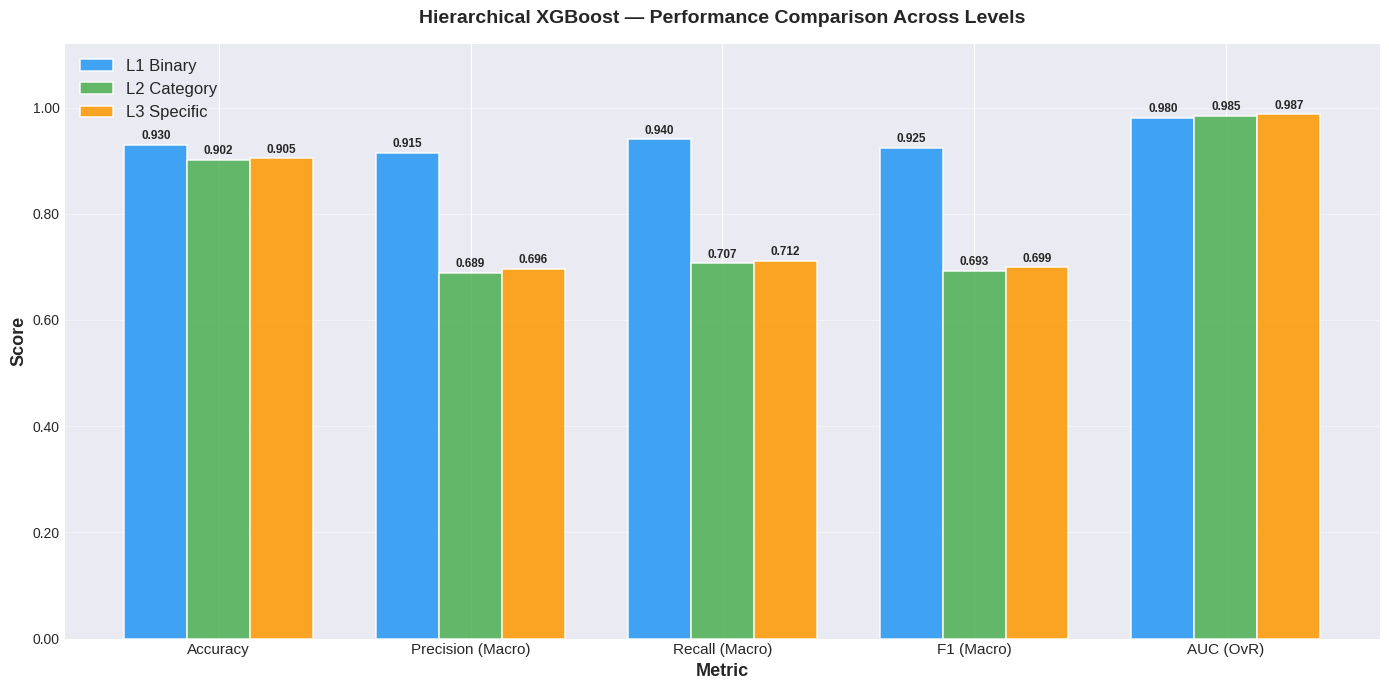


🔄 Running 5-Fold Stratified Cross-Validation (GPU)...
  ⏳ L1 CV (SMOTE inside each fold via ImbPipeline)...
     L1 CV F1-Macro: 0.9252 ± 0.0003
  ⏳ L2 CV (attack samples — SMOTE inside each fold)...
     L2 CV F1-Macro: 0.6911 ± 0.0016
  ⏳ L3 CV (attack samples — SMOTE inside each fold)...
     L3 CV F1-Macro: 0.6977 ± 0.0019

📋 5-Fold Stratified CV Results:


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean F1,Std F1
Level,,,,,,,
L1 Binary,0.9257,0.9247,0.9250,0.9253,0.9253,0.9252,0.0003
L2 Category,0.6883,0.6932,0.6914,0.6913,0.6912,0.6911,0.0016
L3 Specific,0.6964,0.6985,0.7009,0.6952,0.6975,0.6977,0.0019


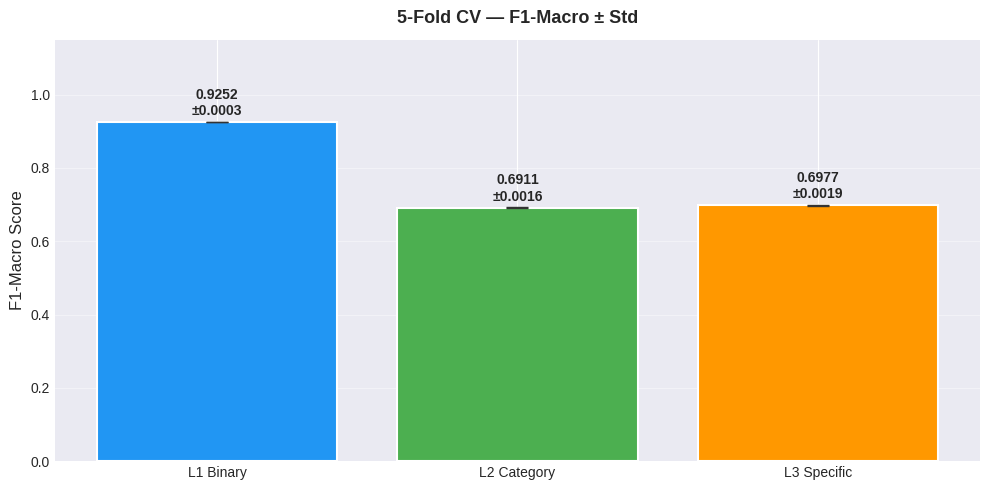

35757

In [13]:
# ============================================================
# BLOCK 12: PERFORMANCE TABLES & METRICS — L1, L2, L3
# FIX: CV uses device=XGB_DEVICE (GPU) — n_jobs removed for GPU
# ============================================================

print('='*70)
print('  PERFORMANCE METRICS — ALL LEVELS')
print('='*70)

# ── Big comparison table ──
perf_table = pd.DataFrame({
    'Level':             ['L1 — Binary', 'L2 — Category', 'L3 — Specific'],
    'Task':              ['Benign vs Attack', 'Attack Category', 'Specific Attack Type'],
    'Test Samples':      [len(y1_test), len(y2_test_enc), len(y3_test_enc)],
    'Classes':           [2, len(le_cat2_classes), len(le_spec2_classes)],
    'Accuracy':          [round(acc_l1,4),  round(acc_l2,4),  round(acc_l3,4)],
    'Precision (Macro)': [round(prec_l1,4), round(prec_l2,4), round(prec_l3,4)],
    'Recall (Macro)':    [round(rec_l1,4),  round(rec_l2,4),  round(rec_l3,4)],
    'F1 (Macro)':        [round(f1_l1,4),   round(f1_l2,4),   round(f1_l3,4)],
    'AUC (OvR)':         [round(auc_l1,4),  round(auc_l2,4),  round(auc_l3,4)],
})

print('\n📋 Comprehensive Performance Comparison Table:')
display(perf_table.set_index('Level'))

# ── Grouped bar chart ──
metrics      = ['Accuracy', 'Precision (Macro)', 'Recall (Macro)', 'F1 (Macro)', 'AUC (OvR)']
levels_plot  = ['L1 Binary', 'L2 Category', 'L3 Specific']
values_plot  = [
    [acc_l1, prec_l1, rec_l1, f1_l1, auc_l1],
    [acc_l2, prec_l2, rec_l2, f1_l2, auc_l2],
    [acc_l3, prec_l3, rec_l3, f1_l3, auc_l3],
]
x     = np.arange(len(metrics))
width = 0.25
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, ax = plt.subplots(figsize=(14, 7))
for i, (level, vals, color) in enumerate(zip(levels_plot, values_plot, colors)):
    bars = ax.bar(x + i*width, vals, width, label=level, color=color,
                  alpha=0.85, edgecolor='white', linewidth=1.2)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{v:.3f}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_xlabel('Metric', fontsize=13, fontweight='bold')
ax.set_ylabel('Score', fontsize=13, fontweight='bold')
ax.set_title('Hierarchical XGBoost — Performance Comparison Across Levels',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.legend(fontsize=12)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

# ── 5-fold Stratified CV ──
# FIX: CV params use device=XGB_DEVICE, no n_jobs (conflicts with GPU)
print('\n🔄 Running 5-Fold Stratified Cross-Validation (GPU)...')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

print('  ⏳ L1 CV (SMOTE inside each fold via ImbPipeline)...')
# FIX: ImbPipeline applies SMOTE inside each fold — same process as actual training.
# Without this, CV trains on imbalanced data while the real model trains on SMOTE data,
# making CV scores an inconsistent measure of the actual model's variance.
pipe_l1 = ImbPipeline([
    ('smote', SMOTE(k_neighbors=5, random_state=RANDOM_STATE)),
    ('clf',   xgb.XGBClassifier(**XGB_PARAMS_BIN))
])
cv1 = cross_val_score(
    pipe_l1, X_train.values, y1_train,   # train rows only
    cv=skf, scoring='f1_macro'
)
cv_results['L1 Binary'] = cv1
print(f'     L1 CV F1-Macro: {cv1.mean():.4f} ± {cv1.std():.4f}')

print('  ⏳ L2 CV (attack samples — SMOTE inside each fold)...')
attack_mask_cv = (y1_train == 1)
X_att_cv       = X_train.values[attack_mask_cv]   # train attack rows only
y2_att_all     = y2_train[attack_mask_cv]
y2_att_enc_cv  = LabelEncoder().fit_transform(y2_att_all)
min_l2_cv = min(Counter(y2_att_enc_cv).values())
k_l2_cv   = min(5, min_l2_cv - 1) if min_l2_cv > 1 else 1
pipe_l2 = ImbPipeline([
    ('smote', SMOTE(k_neighbors=k_l2_cv, random_state=RANDOM_STATE)),
    ('clf',   xgb.XGBClassifier(**XGB_PARAMS_MULTI))
])
cv2 = cross_val_score(
    pipe_l2, X_att_cv, y2_att_enc_cv,
    cv=skf, scoring='f1_macro'
)
cv_results['L2 Category'] = cv2
print(f'     L2 CV F1-Macro: {cv2.mean():.4f} ± {cv2.std():.4f}')

print('  ⏳ L3 CV (attack samples — SMOTE inside each fold)...')
y3_att_all    = y3_train[attack_mask_cv]
y3_att_enc_cv = LabelEncoder().fit_transform(y3_att_all)
min_l3_cv = min(Counter(y3_att_enc_cv).values())
k_l3_cv   = min(5, min_l3_cv - 1) if min_l3_cv > 1 else 1
pipe_l3 = ImbPipeline([
    ('smote', SMOTE(k_neighbors=k_l3_cv, random_state=RANDOM_STATE)),
    ('clf',   xgb.XGBClassifier(**XGB_PARAMS_MULTI))
])
cv3 = cross_val_score(
    pipe_l3, X_att_cv, y3_att_enc_cv,
    cv=skf, scoring='f1_macro'
)
cv_results['L3 Specific'] = cv3
print(f'     L3 CV F1-Macro: {cv3.mean():.4f} ± {cv3.std():.4f}')

cv_table = pd.DataFrame({
    'Level':      list(cv_results.keys()),
    'Fold 1':     [cv_results[k][0] for k in cv_results],
    'Fold 2':     [cv_results[k][1] for k in cv_results],
    'Fold 3':     [cv_results[k][2] for k in cv_results],
    'Fold 4':     [cv_results[k][3] for k in cv_results],
    'Fold 5':     [cv_results[k][4] for k in cv_results],
    'Mean F1':    [cv_results[k].mean() for k in cv_results],
    'Std F1':     [cv_results[k].std()  for k in cv_results],
}).round(4)

print('\n📋 5-Fold Stratified CV Results:')
display(cv_table.set_index('Level'))

# CV bar plot
fig, ax = plt.subplots(figsize=(10, 5))
levels_cv = list(cv_results.keys())
means = [cv_results[k].mean() for k in levels_cv]
stds  = [cv_results[k].std()  for k in levels_cv]
bars = ax.bar(levels_cv, means, color=['#2196F3','#4CAF50','#FF9800'],
              yerr=stds, capsize=8, edgecolor='white', linewidth=1.5,
              error_kw={'elinewidth':2, 'ecolor':'#333'})
for bar, m, s in zip(bars, means, stds):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+s+0.01,
            f'{m:.4f}\n±{s:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('F1-Macro Score', fontsize=12)
ax.set_title('5-Fold CV — F1-Macro ± Std', fontsize=13, fontweight='bold', pad=12)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

gc.collect()

------

## 📈 Block 13: Pareto Feature Importance Plots

  PARETO FEATURE IMPORTANCE PLOTS

📊 L1 Binary — Pareto Feature Importance (Top 20):


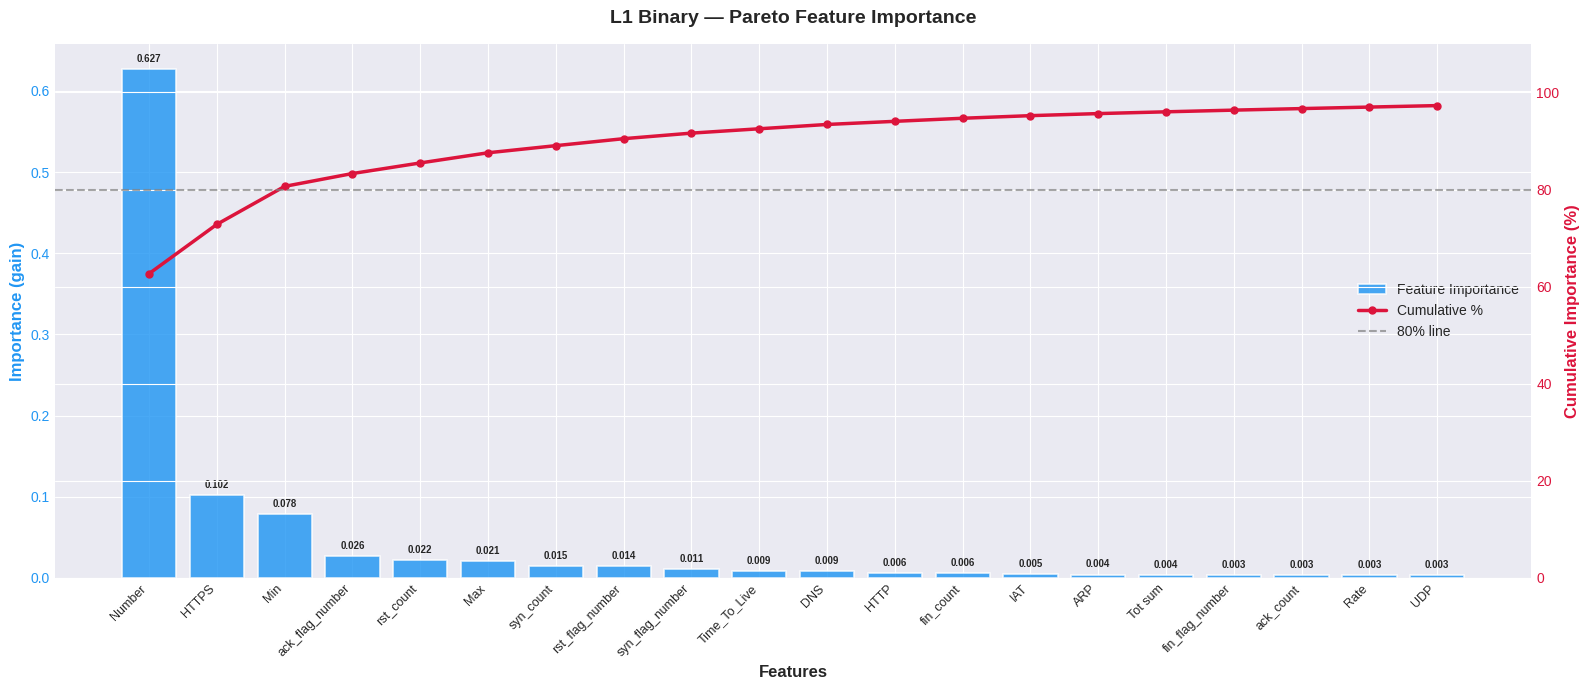

,Feature,Importance,Cumulative %
0,Number,0.6266,62.663898
1,HTTPS,0.1016,72.821800
2,Min,0.0782,80.645103
3,ack_flag_number,0.0265,83.290802
4,rst_count,0.0218,85.469299
5,Max,0.0209,87.564102
6,syn_count,0.0147,89.029503
7,rst_flag_number,0.0144,90.466202
8,syn_flag_number,0.0115,91.612000
9,Time_To_Live,0.0089,92.506203



📊 L2 Category — Pareto Feature Importance (Top 20):


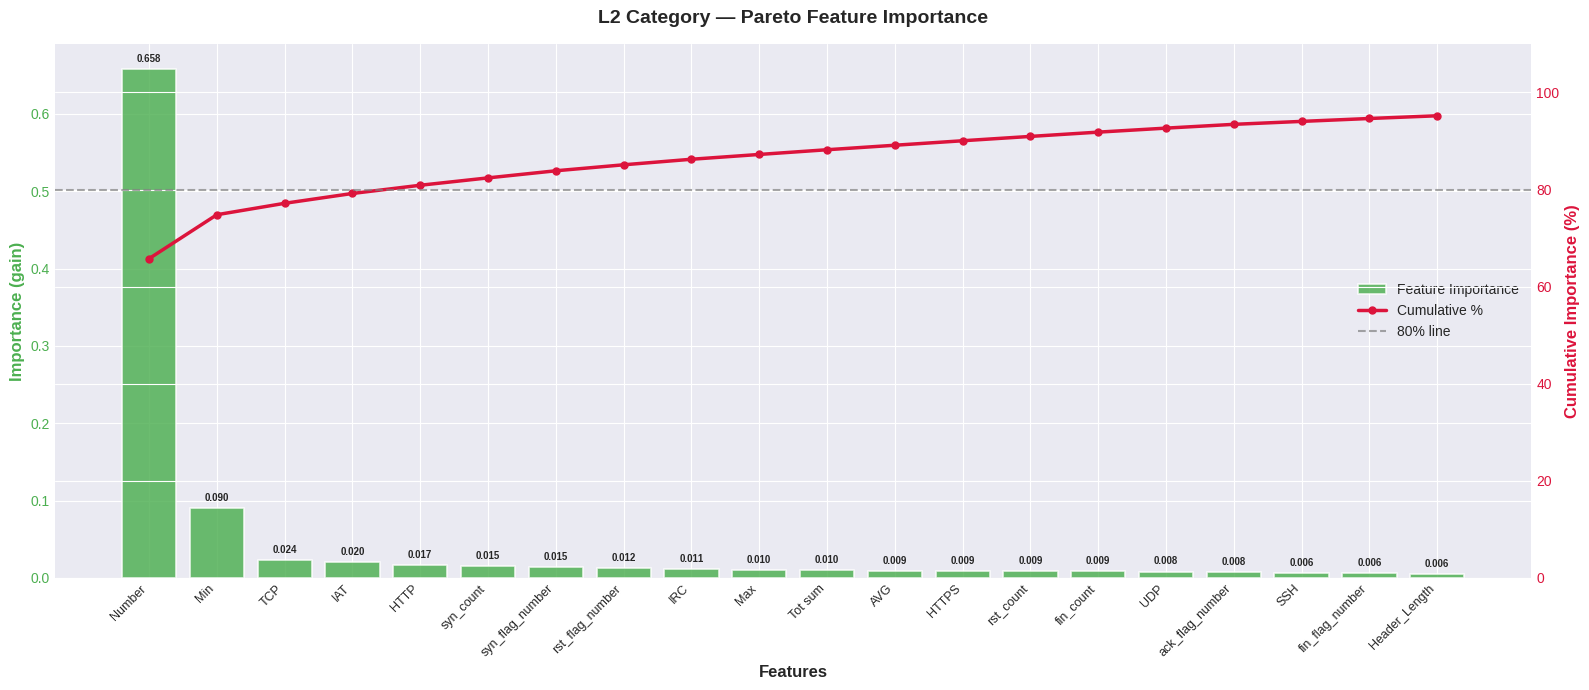

,Feature,Importance,Cumulative %
0,Number,0.6576,65.755898
1,Min,0.0905,74.805199
2,TCP,0.0235,77.158096
3,IAT,0.0203,79.183197
4,HTTP,0.0169,80.874496
5,syn_count,0.0152,82.392197
6,syn_flag_number,0.0146,83.854698
7,rst_flag_number,0.0123,85.087502
8,IRC,0.0114,86.229103
9,Max,0.0099,87.218201



📊 L3 Specific — Pareto Feature Importance (Top 20):


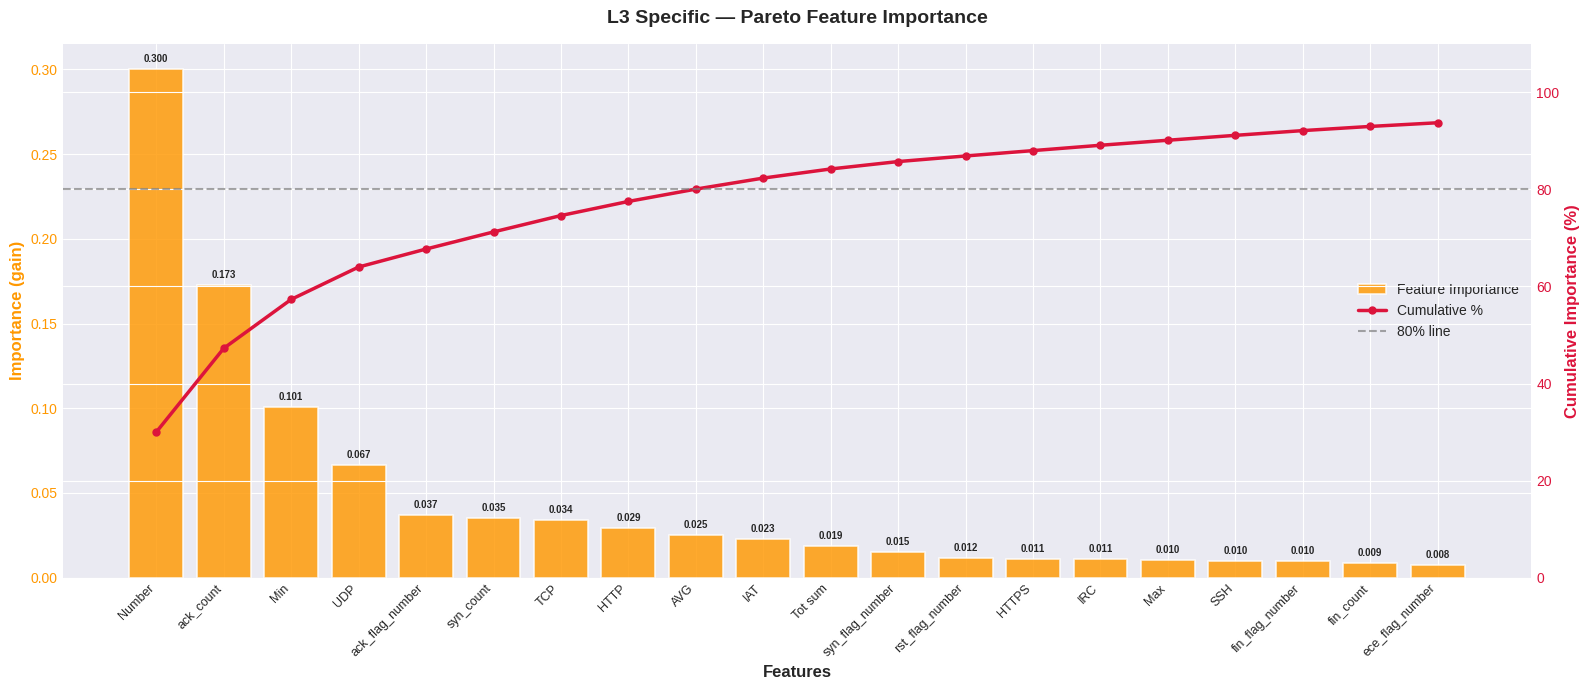

,Feature,Importance,Cumulative %
0,Number,0.3000,30.004499
1,ack_count,0.1726,47.262001
2,Min,0.1008,57.341202
3,UDP,0.0667,64.012497
4,ack_flag_number,0.0371,67.720200
5,syn_count,0.0352,71.244102
6,TCP,0.0338,74.619102
7,HTTP,0.0291,77.526901
8,AVG,0.0254,80.065697
9,IAT,0.0227,82.338303



✅ Pareto plots complete!


In [14]:
# ============================================================
# BLOCK 13: PARETO FEATURE IMPORTANCE PLOTS — L1, L2, L3
# Bar + cumulative line (Pareto-style)
# ============================================================

print('='*70)
print('  PARETO FEATURE IMPORTANCE PLOTS')
print('='*70)

def plot_pareto_importance(model, feature_names, title, color='steelblue', top_n=20):
    """Publication-quality Pareto feature importance: bar + cumulative line."""
    importance = model.feature_importances_
    feat_imp = pd.Series(importance, index=feature_names).sort_values(ascending=False)
    top_feats = feat_imp.head(top_n)
    cumsum = (top_feats.cumsum() / feat_imp.sum() * 100)

    fig, ax1 = plt.subplots(figsize=(16, 7))
    bars = ax1.bar(range(top_n), top_feats.values, color=color,
                   alpha=0.82, edgecolor='white', linewidth=1.2, label='Feature Importance')
    ax1.set_xlabel('Features', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Importance (gain)', fontsize=12, fontweight='bold', color=color)
    ax1.tick_params(axis='y', labelcolor=color)
    ax1.set_xticks(range(top_n))
    ax1.set_xticklabels(top_feats.index, rotation=45, ha='right', fontsize=9)
    for bar, v in zip(bars, top_feats.values):
        ax1.text(bar.get_x()+bar.get_width()/2,
                 bar.get_height() + max(top_feats.values)*0.01,
                 f'{v:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

    ax2 = ax1.twinx()
    ax2.plot(range(top_n), cumsum.values, color='crimson', marker='o',
             linewidth=2.5, markersize=5, label='Cumulative %')
    ax2.axhline(y=80, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='80% line')
    ax2.set_ylabel('Cumulative Importance (%)', fontsize=12, fontweight='bold', color='crimson')
    ax2.tick_params(axis='y', labelcolor='crimson')
    ax2.set_ylim(0, 110)

    lines1, labs1 = ax1.get_legend_handles_labels()
    lines2, labs2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1+lines2, labs1+labs2, loc='center right', fontsize=10)
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.tight_layout()
    plt.show()

    return pd.DataFrame({'Feature': top_feats.index,
                         'Importance': top_feats.values,
                         'Cumulative %': cumsum.values}).round(4)


print('\n📊 L1 Binary — Pareto Feature Importance (Top 20):')
tbl1 = plot_pareto_importance(xgb_l1, feature_cols,
                               'L1 Binary — Pareto Feature Importance', '#2196F3')
display(tbl1.head(10))

print('\n📊 L2 Category — Pareto Feature Importance (Top 20):')
tbl2 = plot_pareto_importance(xgb_l2, feature_cols,
                               'L2 Category — Pareto Feature Importance', '#4CAF50')
display(tbl2.head(10))

print('\n📊 L3 Specific — Pareto Feature Importance (Top 20):')
tbl3 = plot_pareto_importance(xgb_l3, feature_cols,
                               'L3 Specific — Pareto Feature Importance', '#FF9800')
display(tbl3.head(10))

print('\n✅ Pareto plots complete!')

------

## 🧠 Block 14: SHAP Explainability for Each Level

  SHAP EXPLAINABILITY — ALL LEVELS (summary_plot dot)
  1,000 random test samples per tier
  CPU inference on GPU-trained model weights (standard)

--- L1 Binary: SHAP Summary Plot ---


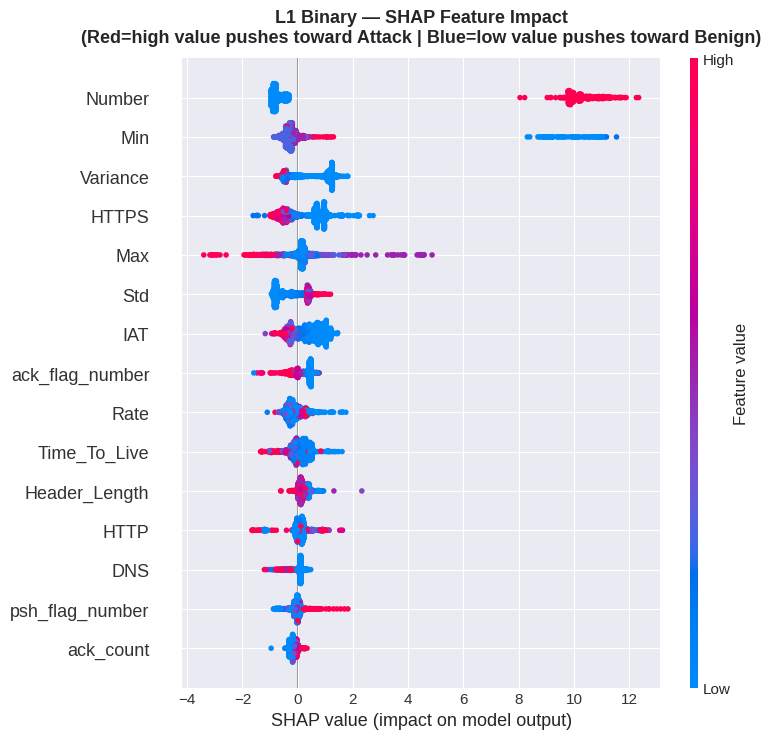


--- L2 Category: SHAP Summary Plot ---
    Multiclass: using class index 4 (highest mean |SHAP|)


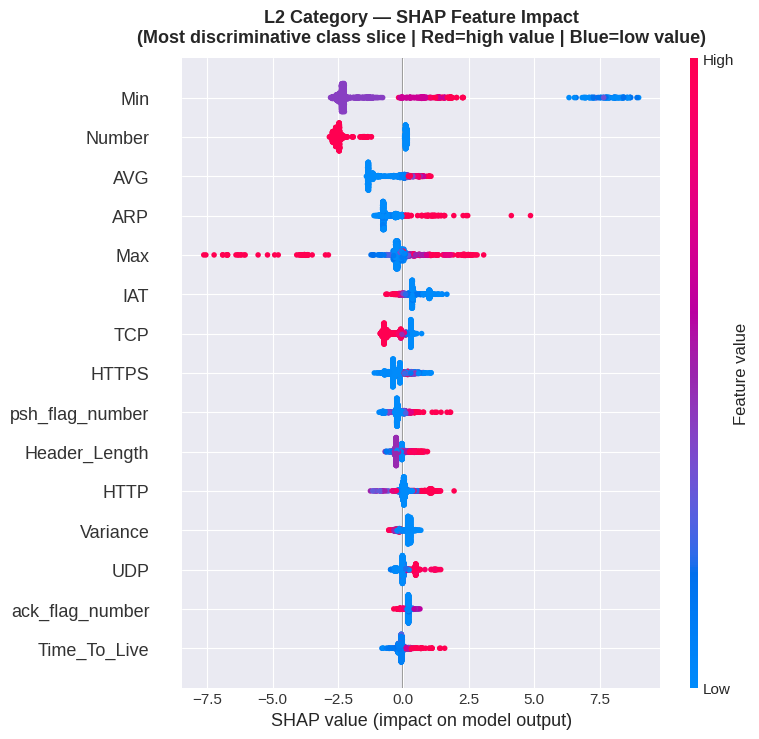


--- L3 Specific: SHAP Summary Plot ---
    Multiclass: using class index 3 (highest mean |SHAP|)


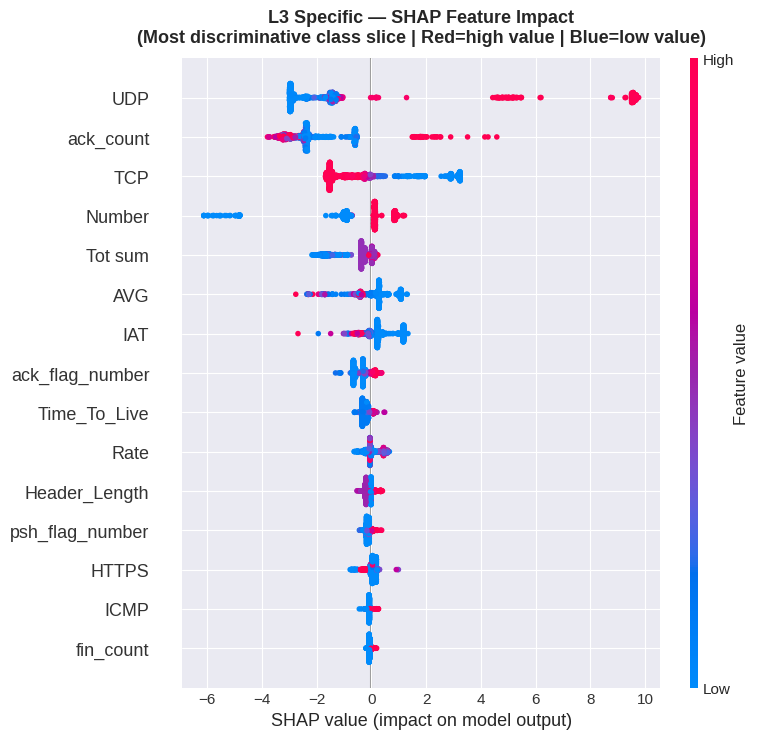


✅ SHAP complete — 3 summary plots generated (one per tier).

How to read each plot:
  Y-axis : Features ranked by mean |SHAP| (top = most important)
  X-axis : SHAP value — magnitude = impact, sign = direction
  Red dot: high feature value  -> pushes prediction toward that class
  Blue dot: low feature value  -> pushes prediction away from that class


In [17]:
# ============================================================
# BLOCK 14.1: SHAP EXPLAINABILITY — L1, L2, L3
# Method: shap.summary_plot (dot) — the single most relevant
# SHAP visualisation for a tree-based XGBoost IDS project.
#
# Why summary_plot (dot) over beeswarm/bar/waterfall:
#   1. Shows feature IMPORTANCE (y-axis ranking by mean|SHAP|)
#   2. Shows DIRECTION of effect (positive = pushes toward that class)
#   3. Shows FEATURE VALUE magnitude (red=high, blue=low)
#   4. One clean, paper-ready figure per tier — no clutter
#   5. Directly actionable: high Number (red) -> Attack;
#      high HTTPS (red) -> Benign suppression, etc.
#   6. Standard in IDS/network security XAI literature
#
# Ref: XAI-XGBoost: Explainable IDS for IoT Systems [1]
#      Explainable AI Framework for Multiclass NIDS [9]
# ============================================================

print('='*70)
print('  SHAP EXPLAINABILITY — ALL LEVELS (summary_plot dot)')
print('='*70)
print('  1,000 random test samples per tier')
print('  CPU inference on GPU-trained model weights (standard)')

SHAP_BG = 1000
rng     = np.random.default_rng(RANDOM_STATE)

# ----------------------------------------------------------------
# Helper: extract a 2-D (n_samples x n_features) SHAP matrix
# from either binary (2-D) or multiclass (3-D list or array).
# For multiclass, picks the class with the highest mean |SHAP|
# so the plot always shows the most discriminative class slice.
# ----------------------------------------------------------------
def get_shap_matrix(shap_values):
    if isinstance(shap_values, list):
        # Old SHAP API: list of (n, f) arrays, one per class
        arr = np.stack(shap_values, axis=2)   # -> (n, f, c)
    else:
        arr = np.array(shap_values)

    if arr.ndim == 3:
        mean_abs = np.mean(np.abs(arr), axis=(0, 1))   # (c,)
        best_cls = int(np.argmax(mean_abs))
        print(f'    Multiclass: using class index {best_cls} (highest mean |SHAP|)')
        return arr[:, :, best_cls]
    return arr   # binary already (n, f)


# ----------------------------------------------------------------
# Unified summary_plot function — one call per tier
# ----------------------------------------------------------------
def shap_summary_plot(model, X_sample, feature_names, title, max_display=15):
    """
    Compute SHAP values with TreeExplainer and draw a dot summary plot.
    Compatible with binary and multiclass XGBoost models.
    """
    explainer   = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_sample)   # raw numpy arrays
    shap_matrix = get_shap_matrix(shap_values)       # always (n, f)

    plt.figure(figsize=(10, 7))
    shap.summary_plot(
        shap_matrix,
        X_sample,
        feature_names=feature_names,
        max_display=max_display,
        plot_type='dot',    # dot: importance + direction + value colour
        show=False
    )
    plt.title(title, fontsize=13, fontweight='bold', pad=12)
    plt.tight_layout()
    plt.show()
    return shap_matrix


# ================================================================
# L1 — Binary (Benign vs Attack)
# ================================================================
print('\n--- L1 Binary: SHAP Summary Plot ---')
bg_idx1 = rng.choice(len(X_test), size=min(SHAP_BG, len(X_test)), replace=False)
X_shap1 = X_test.values[bg_idx1]

sv1 = shap_summary_plot(
    xgb_l1, X_shap1, feature_cols,
    'L1 Binary — SHAP Feature Impact\n'
    '(Red=high value pushes toward Attack | Blue=low value pushes toward Benign)'
)
del sv1; gc.collect()


# ================================================================
# L2 — Category (6 attack categories)
# ================================================================
print('\n--- L2 Category: SHAP Summary Plot ---')
bg_idx2 = rng.choice(len(X2_test), size=min(SHAP_BG, len(X2_test)), replace=False)
X_shap2 = X2_test[bg_idx2]

sv2 = shap_summary_plot(
    xgb_l2, X_shap2, feature_cols,
    'L2 Category — SHAP Feature Impact\n'
    '(Most discriminative class slice | Red=high value | Blue=low value)'
)
del sv2; gc.collect()


# ================================================================
# L3 — Specific Attack (9 specific attack types)
# ================================================================
print('\n--- L3 Specific: SHAP Summary Plot ---')
bg_idx3 = rng.choice(len(X3_test), size=min(SHAP_BG, len(X3_test)), replace=False)
X_shap3 = X3_test[bg_idx3]

sv3 = shap_summary_plot(
    xgb_l3, X_shap3, feature_cols,
    'L3 Specific — SHAP Feature Impact\n'
    '(Most discriminative class slice | Red=high value | Blue=low value)'
)
del sv3; gc.collect()

print('\n✅ SHAP complete — 3 summary plots generated (one per tier).')
print('\nHow to read each plot:')
print('  Y-axis : Features ranked by mean |SHAP| (top = most important)')
print('  X-axis : SHAP value — magnitude = impact, sign = direction')
print('  Red dot: high feature value  -> pushes prediction toward that class')
print('  Blue dot: low feature value  -> pushes prediction away from that class')

## 🏆 Block 15: Conclusion — Final Accuracy Summary


  🎓 HIERARCHICAL XAI-XGBoost IDS — FINAL SUMMARY
  CICIoT2023 | SMOTE + XGBoost + SHAP

📌 PAPER:
   Hierarchical XAI-Enhanced XGBoost with SMOTE for
   Multiclass Intrusion Detection in IoT Networks (CICIoT2023)

🏗️  ARCHITECTURE:
   • 3-Level Hierarchical XGBoost (branched inference)
   • SMOTE (k=5) oversampling at each training level (CPU)
   • XGBoost training: CUDA accelerated
   • SHAP TreeExplainer for XAI

📊 FINAL PERFORMANCE RESULTS:

────────────────────────────────────────────────────
  Level            | Accuracy | F1-Macro |      AUC
────────────────────────────────────────────────────
  L1 Binary        |   0.9303 |   0.9247 |   0.9801
  L2 Category      |   0.9019 |   0.6931 |   0.9850
  L3 Specific      |   0.9045 |   0.6988 |   0.9872
────────────────────────────────────────────────────

📋 DATASET STATS:
   Total samples : 1,062,947
   Features      : 39
   L1 Classes    : 2  (Benign, Attack)
   L2 Classes    : 6
   L3 Classes    : 9

📚 REFERENCES:
   [1] XAI-XGBoost:

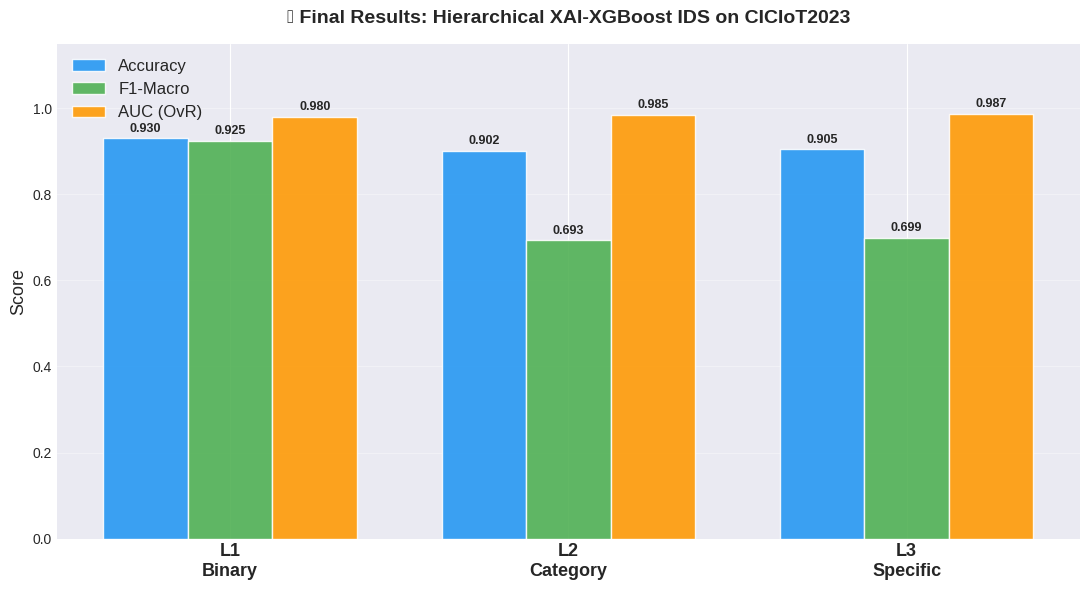


🎉 All done! Notebook complete.


In [16]:
# ============================================================
# BLOCK 15: CONCLUSION — FINAL ACCURACY SUMMARY
# FIX: le_cat2.classes_ / le_spec2.classes_ → le_cat2_classes / le_spec2_classes
# ============================================================

SEP = '─' * 52

print('\n' + '='*70)
print('  🎓 HIERARCHICAL XAI-XGBoost IDS — FINAL SUMMARY')
print('  CICIoT2023 | SMOTE + XGBoost + SHAP')
print('='*70)

print(f"""
📌 PAPER:
   Hierarchical XAI-Enhanced XGBoost with SMOTE for
   Multiclass Intrusion Detection in IoT Networks (CICIoT2023)

🏗️  ARCHITECTURE:
   • 3-Level Hierarchical XGBoost (branched inference)
   • SMOTE (k=5) oversampling at each training level (CPU)
   • XGBoost training: {XGB_DEVICE.upper()} accelerated
   • SHAP TreeExplainer for XAI

📊 FINAL PERFORMANCE RESULTS:
""")

print(SEP)
print(f'  {"Level":<16} | {"Accuracy":>8} | {"F1-Macro":>8} | {"AUC":>8}')
print(SEP)
print(f'  {"L1 Binary":<16} | {acc_l1:>8.4f} | {f1_l1:>8.4f} | {auc_l1:>8.4f}')
print(f'  {"L2 Category":<16} | {acc_l2:>8.4f} | {f1_l2:>8.4f} | {auc_l2:>8.4f}')
print(f'  {"L3 Specific":<16} | {acc_l3:>8.4f} | {f1_l3:>8.4f} | {auc_l3:>8.4f}')
print(SEP)

print(f"""
📋 DATASET STATS:
   Total samples : {len(df):,}
   Features      : {len(feature_cols)}
   L1 Classes    : 2  (Benign, Attack)
   L2 Classes    : {len(le_cat2_classes)}
   L3 Classes    : {len(le_spec2_classes)}

📚 REFERENCES:
   [1] XAI-XGBoost: Explainable IDS for Securing IoT Systems
   [2] Lean & Modular Two-Stage IDS for IoT Traffic
   [3] Scalable Hierarchical IDS for Internet of Vehicles (Uddin et al., 2025)
   [4] Sample-Based, Multistage ML Pipeline for Scalable IoT Threat Detection
   [5] Hierarchical IDS — ML & Knowledge Model (Sarnovsky & Paralic, 2020)
   [6] Multi-Stage Adversarial Defense for DDoS Detection in IoT
""")
print(f'⏰ Completed: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')

# Final visual summary bar chart
fig, ax = plt.subplots(figsize=(11, 6))
levels_fin = ['L1\nBinary', 'L2\nCategory', 'L3\nSpecific']
x_pos = np.arange(3)
w = 0.25
b1 = ax.bar(x_pos-w, [acc_l1,acc_l2,acc_l3],  w, label='Accuracy',  color='#2196F3', alpha=0.88, edgecolor='white')
b2 = ax.bar(x_pos,   [f1_l1,f1_l2,f1_l3],     w, label='F1-Macro',  color='#4CAF50', alpha=0.88, edgecolor='white')
b3 = ax.bar(x_pos+w, [auc_l1,auc_l2,auc_l3],  w, label='AUC (OvR)', color='#FF9800', alpha=0.88, edgecolor='white')
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.008,
                f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(levels_fin, fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('🏆 Final Results: Hierarchical XAI-XGBoost IDS on CICIoT2023',
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=12)
ax.grid(axis='y', alpha=0.35)
plt.tight_layout()
plt.show()

print('\n🎉 All done! Notebook complete.')